<a href="https://colab.research.google.com/github/MiloHS/waste-managment/blob/main/Waste_Managment_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import os
import gspread
from google.auth import default
from google.oauth2.service_account import Credentials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import geopandas as gpd
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

In [16]:
def get_gspread_client():
    try:
        from google.colab import auth  # only exists in Colab
        auth.authenticate_user()
        creds, _ = default()
        return gspread.authorize(creds)
    except Exception:
        sa_path = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
        if not sa_path:
            raise RuntimeError(
                "Not in Colab, and GOOGLE_APPLICATION_CREDENTIALS is not set. "
                "Set it to a service account JSON path."
            )
        scopes = ["https://www.googleapis.com/auth/spreadsheets.readonly"]
        creds = Credentials.from_service_account_file(sa_path, scopes=scopes)
        return gspread.authorize(creds)

gc = get_gspread_client()
sh = gc.open("Waste Managment Data")


In [17]:
# oad worksheets

# Ball report by state
ball = pd.DataFrame(sh.get_worksheet(0).get_all_records())

# Factors by state
factors = pd.DataFrame(sh.get_worksheet(1).get_all_records())

# Factors-by-material mapping
factors_by_material = pd.DataFrame(sh.get_worksheet(2).get_all_records())

print("ball columns:", ball.columns.tolist())
print("factors columns:", factors.columns.tolist())
print("factors_by_material columns:", factors_by_material.columns.tolist())



ball columns: ['Rank', 'STATE', 'RECYCLING_RATE_WITHOUT_FFP', 'ALUMINUM_CANS', 'STEEL_CANS', 'GLASS_BOTTLES_AND_JARS', 'PET_BOTTLES', 'HDPE_BOTTLES', 'RIGID_PLASTICS', 'CLOSED_LOOP_RECYCLING_WITHOUT_FFP', 'MATERIAL_VALUE_CAPTURED_USDM_WITHOUT_FFP', 'MATERIAL_VALUE_CAPTURED_PCT_WITHOUT_FFP', 'RECYCLING_REFUND_STATE']
factors columns: ['STATE', 'MRF_FACILITIES', 'TRANSFER_FACILITIES', 'METALS_RECYCLING_FACILITIES', 'GLASS_RECYCLING_FACILITY', 'PLASTIC_RECYCLING_FACILITIES', 'PAPER_RECYCLING_FACILITIES', 'ELECTRONICS_RECYCLING_FACILITIES', 'NUMBER_OF_SECONDARY_GLASS_PROCESSORS', 'EPR_PACKAGING', 'EWASTE_LAW', 'BOTTLE_BILL', 'PLASTIC_BAG_BAN', 'ENVIRONMENTAL_AND_NATURAL_RESOURCES_DEPARTMENT_SPENDING_2015', 'MEDIAN_HOUSEHOLD_INCOME', 'PARTY_OF_GOVERNOR_MAYOR_FOR_DC', 'POPULATION', 'POPULATION_DENSITY_2020_PER_SQ_MILE', 'PERCENT_BACHELORS_OR_HIGHER', 'PERCENT_ADVANCED_DEGREE', 'UNEMPLOYMENT_AUG2025', 'POVERTY_RATE_PCT']
factors_by_material columns: ['ALUMINUM_CANS', 'STEEL_CANS', 'GLASS_BOTT

In [18]:
ball_numeric_cols = [
    "Rank",
    "RECYCLING_RATE_WITHOUT_FFP",
    "ALUMINUM_CANS",
    "STEEL_CANS",
    "GLASS_BOTTLES_AND_JARS",
    "PET_BOTTLES",
    "HDPE_BOTTLES",
    "RIGID_PLASTICS",
    "CLOSED_LOOP_RECYCLING_WITHOUT_FFP",
    "MATERIAL_VALUE_CAPTURED_USDM_WITHOUT_FFP",
    "MATERIAL_VALUE_CAPTURED_PCT_WITHOUT_FFP",
]

for col in ball_numeric_cols:
    if col in ball.columns:
        ball[col] = pd.to_numeric(ball[col], errors="coerce")

if "RECYCLING_REFUND_STATE" in ball.columns:
    ball["RECYCLING_REFUND_STATE"] = (
        ball["RECYCLING_REFUND_STATE"]
        .astype(str)
        .str.upper()
        .isin(["TRUE", "1", "YES", "Y"])
    )


factors_numeric_cols = [
    "MRF_FACILITIES",
    "TRANSFER_FACILITIES",
    "METALS_RECYCLING_FACILITIES",
    "GLASS_RECYCLING_FACILITY",
    "PLASTIC_RECYCLING_FACILITIES",
    "PAPER_RECYCLING_FACILITIES",
    "ELECTRONICS_RECYCLING_FACILITIES",
    "NUMBER_OF_SECONDARY_GLASS_PROCESSORS",
    "ENVIRONMENTAL_AND_NATURAL_RESOURCES_DEPARTMENT_SPENDING_2015",
    "MEDIAN_HOUSEHOLD_INCOME",
    "POPULATION",
    "POPULATION_DENSITY_2020_PER_SQ_MILE",
    "PERCENT_BACHELORS_OR_HIGHER",
    "PERCENT_ADVANCED_DEGREE",
    "UNEMPLOYMENT_AUG2025",
    "POVERTY_RATE_PCT",
]

for col in factors_numeric_cols:
    if col in factors.columns:
        factors[col] = pd.to_numeric(factors[col], errors="coerce")

policy_flag_cols = ["EPR_PACKAGING", "EWASTE_LAW", "BOTTLE_BILL", "PLASTIC_BAG_BAN"]
for col in policy_flag_cols:
    if col in factors.columns:
        factors[col] = pd.to_numeric(factors[col], errors="coerce").fillna(0).astype(int)


ball["STATE_KEY"] = ball["STATE"].astype(str).str.upper().str.strip()
factors["STATE_KEY"] = factors["STATE"].astype(str).str.upper().str.strip()

merged = pd.merge(
    ball,
    factors,
    on="STATE_KEY",
    suffixes=("_BALL", "_FAC"),
    how="inner",
)

pop_col = "POPULATION"
mrf_col = "MRF_FACILITIES"
env_spend_col = "ENVIRONMENTAL_AND_NATURAL_RESOURCES_DEPARTMENT_SPENDING_2015"
recycling_rate_col = "RECYCLING_RATE_WITHOUT_FFP"
deposit_col = "RECYCLING_REFUND_STATE"

merged["MRF_FACILITIES_PER_MILLION"] = merged[mrf_col] / (merged[pop_col] / 1_000_000)

merged["ENV_SPENDING_PER_CAPITA"] = merged[env_spend_col] * 1e6 / merged[pop_col]

materials = [
    "ALUMINUM_CANS",
    "STEEL_CANS",
    "GLASS_BOTTLES_AND_JARS",
    "PET_BOTTLES",
    "HDPE_BOTTLES",
    "RIGID_PLASTICS",
]

container_materials = [
    "ALUMINUM_CANS",
    "STEEL_CANS",
    "GLASS_BOTTLES_AND_JARS",
    "PET_BOTTLES",
    "HDPE_BOTTLES",
]

merged["CONTAINER_RECYCLING_RATE"] = merged[container_materials].mean(axis=1)

print("ball shape:", ball.shape)
print("factors shape:", factors.shape)
print("factors_by_material shape:", factors_by_material.shape)
print("merged shape:", merged.shape)
merged.head()



ball shape: (50, 14)
factors shape: (50, 23)
factors_by_material shape: (13, 6)
merged shape: (50, 39)


,Rank,STATE_BALL,RECYCLING_RATE_WITHOUT_FFP,ALUMINUM_CANS,STEEL_CANS,GLASS_BOTTLES_AND_JARS,PET_BOTTLES,HDPE_BOTTLES,RIGID_PLASTICS,CLOSED_LOOP_RECYCLING_WITHOUT_FFP,...,PARTY_OF_GOVERNOR_MAYOR_FOR_DC,POPULATION,POPULATION_DENSITY_2020_PER_SQ_MILE,PERCENT_BACHELORS_OR_HIGHER,PERCENT_ADVANCED_DEGREE,UNEMPLOYMENT_AUG2025,POVERTY_RATE_PCT,MRF_FACILITIES_PER_MILLION,ENV_SPENDING_PER_CAPITA,CONTAINER_RECYCLING_RATE
0,43,ALABAMA,0.08,0.15,0.09,0.10,0.05,0.08,0.05,0.03,...,R,5157699.0,99.0,27.4,10.8,2.9,11.3,0.581655,1.155333e+08,0.094
1,47,ALASKA,0.06,0.13,0.08,0.07,0.03,0.03,0.02,0.02,...,R,740133.0,1.3,32.8,11.9,4.7,6.8,0.000000,1.179934e+08,0.068
2,34,ARIZONA,0.12,0.14,0.16,0.14,0.10,0.17,0.10,0.06,...,D,7582384.0,62.9,32.4,12.6,4.1,8.9,0.395654,2.745317e+07,0.142
3,39,ARKANSAS,0.11,0.11,0.11,0.16,0.05,0.14,0.07,0.03,...,R,3088354.0,58.0,25.3,9.4,3.8,11.5,3.561768,1.680132e+07,0.114
4,7,CALIFORNIA,0.41,0.77,0.29,0.49,0.56,0.24,0.30,0.33,...,D,39431263.0,253.6,36.2,14.0,5.5,8.4,1.775241,2.309842e+08,0.470


In [19]:
STATE_ABBREV = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY",
    "District of Columbia": "DC",
}

def plot_state_recycling_choropleth_matplotlib(
    merged_df,
    rate_col="RECYCLING_RATE_WITHOUT_FFP",
    state_col="STATE_BALL",
    cmap="Greens",
    save_path=None,
):
    """
    US choropleth of recycling rate by state.
    """

    df = merged_df[[state_col, rate_col]].copy()
    df[rate_col] = pd.to_numeric(df[rate_col], errors="coerce")
    df[state_col] = df[state_col].astype(str).str.strip()
    df = df.dropna(subset=[rate_col])

    abbrev_values = set(STATE_ABBREV.values())
    name_to_code = {k.upper(): v for k, v in STATE_ABBREV.items()}

    df["STATE_CODE"] = df[state_col].str.upper()
    frac_valid_codes = df["STATE_CODE"].isin(abbrev_values).mean()

    if frac_valid_codes < 0.5:
        df["STATE_CODE"] = df[state_col].str.upper().map(name_to_code)

    df = df.dropna(subset=["STATE_CODE"])

    shp_url = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_5m.zip"
    states = gpd.read_file(shp_url)

    states = states[~states["STUSPS"].isin(["AK", "HI", "VI", "GU", "MP", "AS", "PR"])]

    states = states.to_crs("EPSG:5070")

    map_df = states.merge(
        df,
        left_on="STUSPS",
        right_on="STATE_CODE",
        how="left",
    )

    fig = plt.figure(figsize=(10, 6), dpi=300)
    fig.patch.set_alpha(0)
    ax = fig.add_axes([0.18, 0.05, 0.80, 0.90])
    ax.set_facecolor("none")

    vmin = map_df[rate_col].min()
    vmax = map_df[rate_col].max()
    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    map_df.plot(
        column=rate_col,
        ax=ax,
        cmap=cmap,
        linewidth=0.5,
        edgecolor="white",
        legend=False,
        missing_kwds={
            "color": "lightgray",
            "edgecolor": "white",
            "label": "No data",
        },
    )

    ax.set_title(
        "Overall Recycling Rate by State",
        fontsize=18,
        pad=12,
        fontweight="bold",
    )
    ax.set_axis_off()

    cax = fig.add_axes([0.04, 0.20, 0.02, 0.60])
    cax.set_facecolor("none")
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("Recycling rate", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    plt.tight_layout(rect=[0.18, 0.05, 1.0, 0.95])

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Saved choropleth to: {save_path}")

    plt.show()


def plot_average_by_material(merged_df, material_cols, save_path=None):
    """
    Bar chart of average recycling rate by material across states,
    sorted from lowest to highest.
    """
    means = merged_df[material_cols].mean().sort_values(ascending=True)

    label_map = {
        "ALUMINUM_CANS": "Aluminum cans",
        "STEEL_CANS": "Steel cans",
        "GLASS_BOTTLES_AND_JARS": "Glass bottles & jars",
        "PET_BOTTLES": "PET bottles",
        "HDPE_BOTTLES": "HDPE bottles",
        "RIGID_PLASTICS": "Rigid plastics",
    }
    readable_labels = [label_map.get(col, col) for col in means.index]

    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    x = range(len(means))
    bars = ax.bar(x, means.values)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks(x)
    ax.set_xticklabels(readable_labels, rotation=45, ha="right", fontsize=11)
    ax.set_ylabel("Recycling rate", fontsize=12)
    ax.set_title("Average Recycling Rate by Material Across States",
                 fontsize=16, pad=10, fontweight="bold")

    ax.tick_params(axis="y", labelsize=11)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Saved figure to: {save_path}")

    plt.show()
def plot_deposit_boxplot_containers(
    merged_df,
    rate_col="CONTAINER_RECYCLING_RATE",
    deposit_col="RECYCLING_REFUND_STATE",
    save_path=None,
):
    """
    Boxplot of beverage-container recycling rate in deposit vs non-deposit
    states.
    """
    has_deposit = merged_df[merged_df[deposit_col] == True][rate_col]
    no_deposit = merged_df[merged_df[deposit_col] == False][rate_col]

    fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=300)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    bp = ax.boxplot(
        [no_deposit.dropna(), has_deposit.dropna()],
        labels=["No refund", "Refund (bottle bill)"],
        showmeans=True,
        patch_artist=True,
    )

    for box in bp["boxes"]:
        box.set_alpha(0.8)
        box.set_linewidth(1.2)
    for whisker in bp["whiskers"]:
        whisker.set_linewidth(1.0)
    for cap in bp["caps"]:
        cap.set_linewidth(1.0)
    for median in bp["medians"]:
        median.set_linewidth(1.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylabel("Beverage container recycling rate", fontsize=12)
    ax.set_title(
        "Beverage Container Recycling\nDeposit vs Non-Deposit States",
        fontsize=16,
        pad=10,
        fontweight="bold",
    )

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Saved figure to: {save_path}")

    plt.show()

def plot_scatter_vs_factor(
    df,
    x_col,
    y_col,
    x_label=None,
    y_label=None,
    title=None,
    save_path=None,
    label_outliers=False,
    n_labels=3,
):
    """
    Scatter plot of overall recycling vs a factor.
    """
    import statsmodels.api as sm

    base = df[[x_col, y_col]].dropna().copy()

    fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    ax.scatter(
        base[x_col],
        base[y_col],
        s=40,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )

    ax.set_xlabel(x_label if x_label else x_col, fontsize=12)
    ax.set_ylabel(y_label if y_label else y_col, fontsize=12)
    ax.set_title(
        title if title else f"{y_col} vs {x_col}",
        fontsize=16,
        pad=10,
        fontweight="bold",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    if label_outliers:
        state_cols = [c for c in df.columns if "STATE" in c.upper()]
        state_col = state_cols[0] if state_cols else None

        if state_col is not None:
            data = df[[x_col, y_col, state_col]].dropna().copy()

            X = sm.add_constant(data[[x_col]])
            model = sm.OLS(data[y_col], X).fit()
            data["PRED"] = model.predict(X)
            data["RESID"] = data[y_col] - data["PRED"]

            state_labels = data[state_col].astype(str).str.strip()
            if "STATE_ABBREV" in globals():
                abbrev_set = set(STATE_ABBREV.values())
                name_to_code = {k.upper(): v for k, v in STATE_ABBREV.items()}
                upper = state_labels.str.upper()
                mapped = upper.map(name_to_code)
                is_code = upper.isin(abbrev_set)
                mapped = mapped.where(~is_code, state_labels)
                state_labels = mapped.fillna(state_labels)
            data["STATE_LABEL"] = state_labels

            over = (
                data[data["RESID"] > 0]
                .sort_values("RESID", ascending=False)
                .head(n_labels)
            )
            under = (
                data[data["RESID"] < 0]
                .sort_values("RESID", ascending=True)
                .head(n_labels)
            )

            if not over.empty:
                ax.scatter(over[x_col], over[y_col], s=60, edgecolor="black")
            if not under.empty:
                ax.scatter(under[x_col], under[y_col], s=60, edgecolor="black")

            ymin, ymax = ax.get_ylim()
            y_range = ymax - ymin if ymax > ymin else 1.0

            if not over.empty:
                for _, row in over.iterrows():
                    y_val = row[y_col]
                    if y_val > ymax - 0.25 * y_range:
                        dy = -6
                        va = "top"
                    elif y_val < ymin + 0.25 * y_range:
                        dy = 6
                        va = "bottom"
                    else:
                        dy = 6
                        va = "bottom"

                    ax.annotate(
                        str(row["STATE_LABEL"]),
                        xy=(row[x_col], y_val),
                        xytext=(0, dy),
                        textcoords="offset points",
                        ha="center",
                        va=va,
                        fontsize=8,
                        fontweight="bold",
                    )

            if not under.empty:
                for _, row in under.iterrows():
                    y_val = row[y_col]
                    if y_val < ymin + 0.25 * y_range:
                        dy = 6
                        va = "bottom"
                    else:
                        dy = -6
                        va = "top"

                    ax.annotate(
                        str(row["STATE_LABEL"]),
                        xy=(row[x_col], y_val),
                        xytext=(0, dy),
                        textcoords="offset points",
                        ha="center",
                        va=va,
                        fontsize=8,
                        fontweight="bold",
                    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Saved figure to: {save_path}")

    plt.show()


/tmp/ipython-input-111645162.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.18, 0.05, 1.0, 0.95])


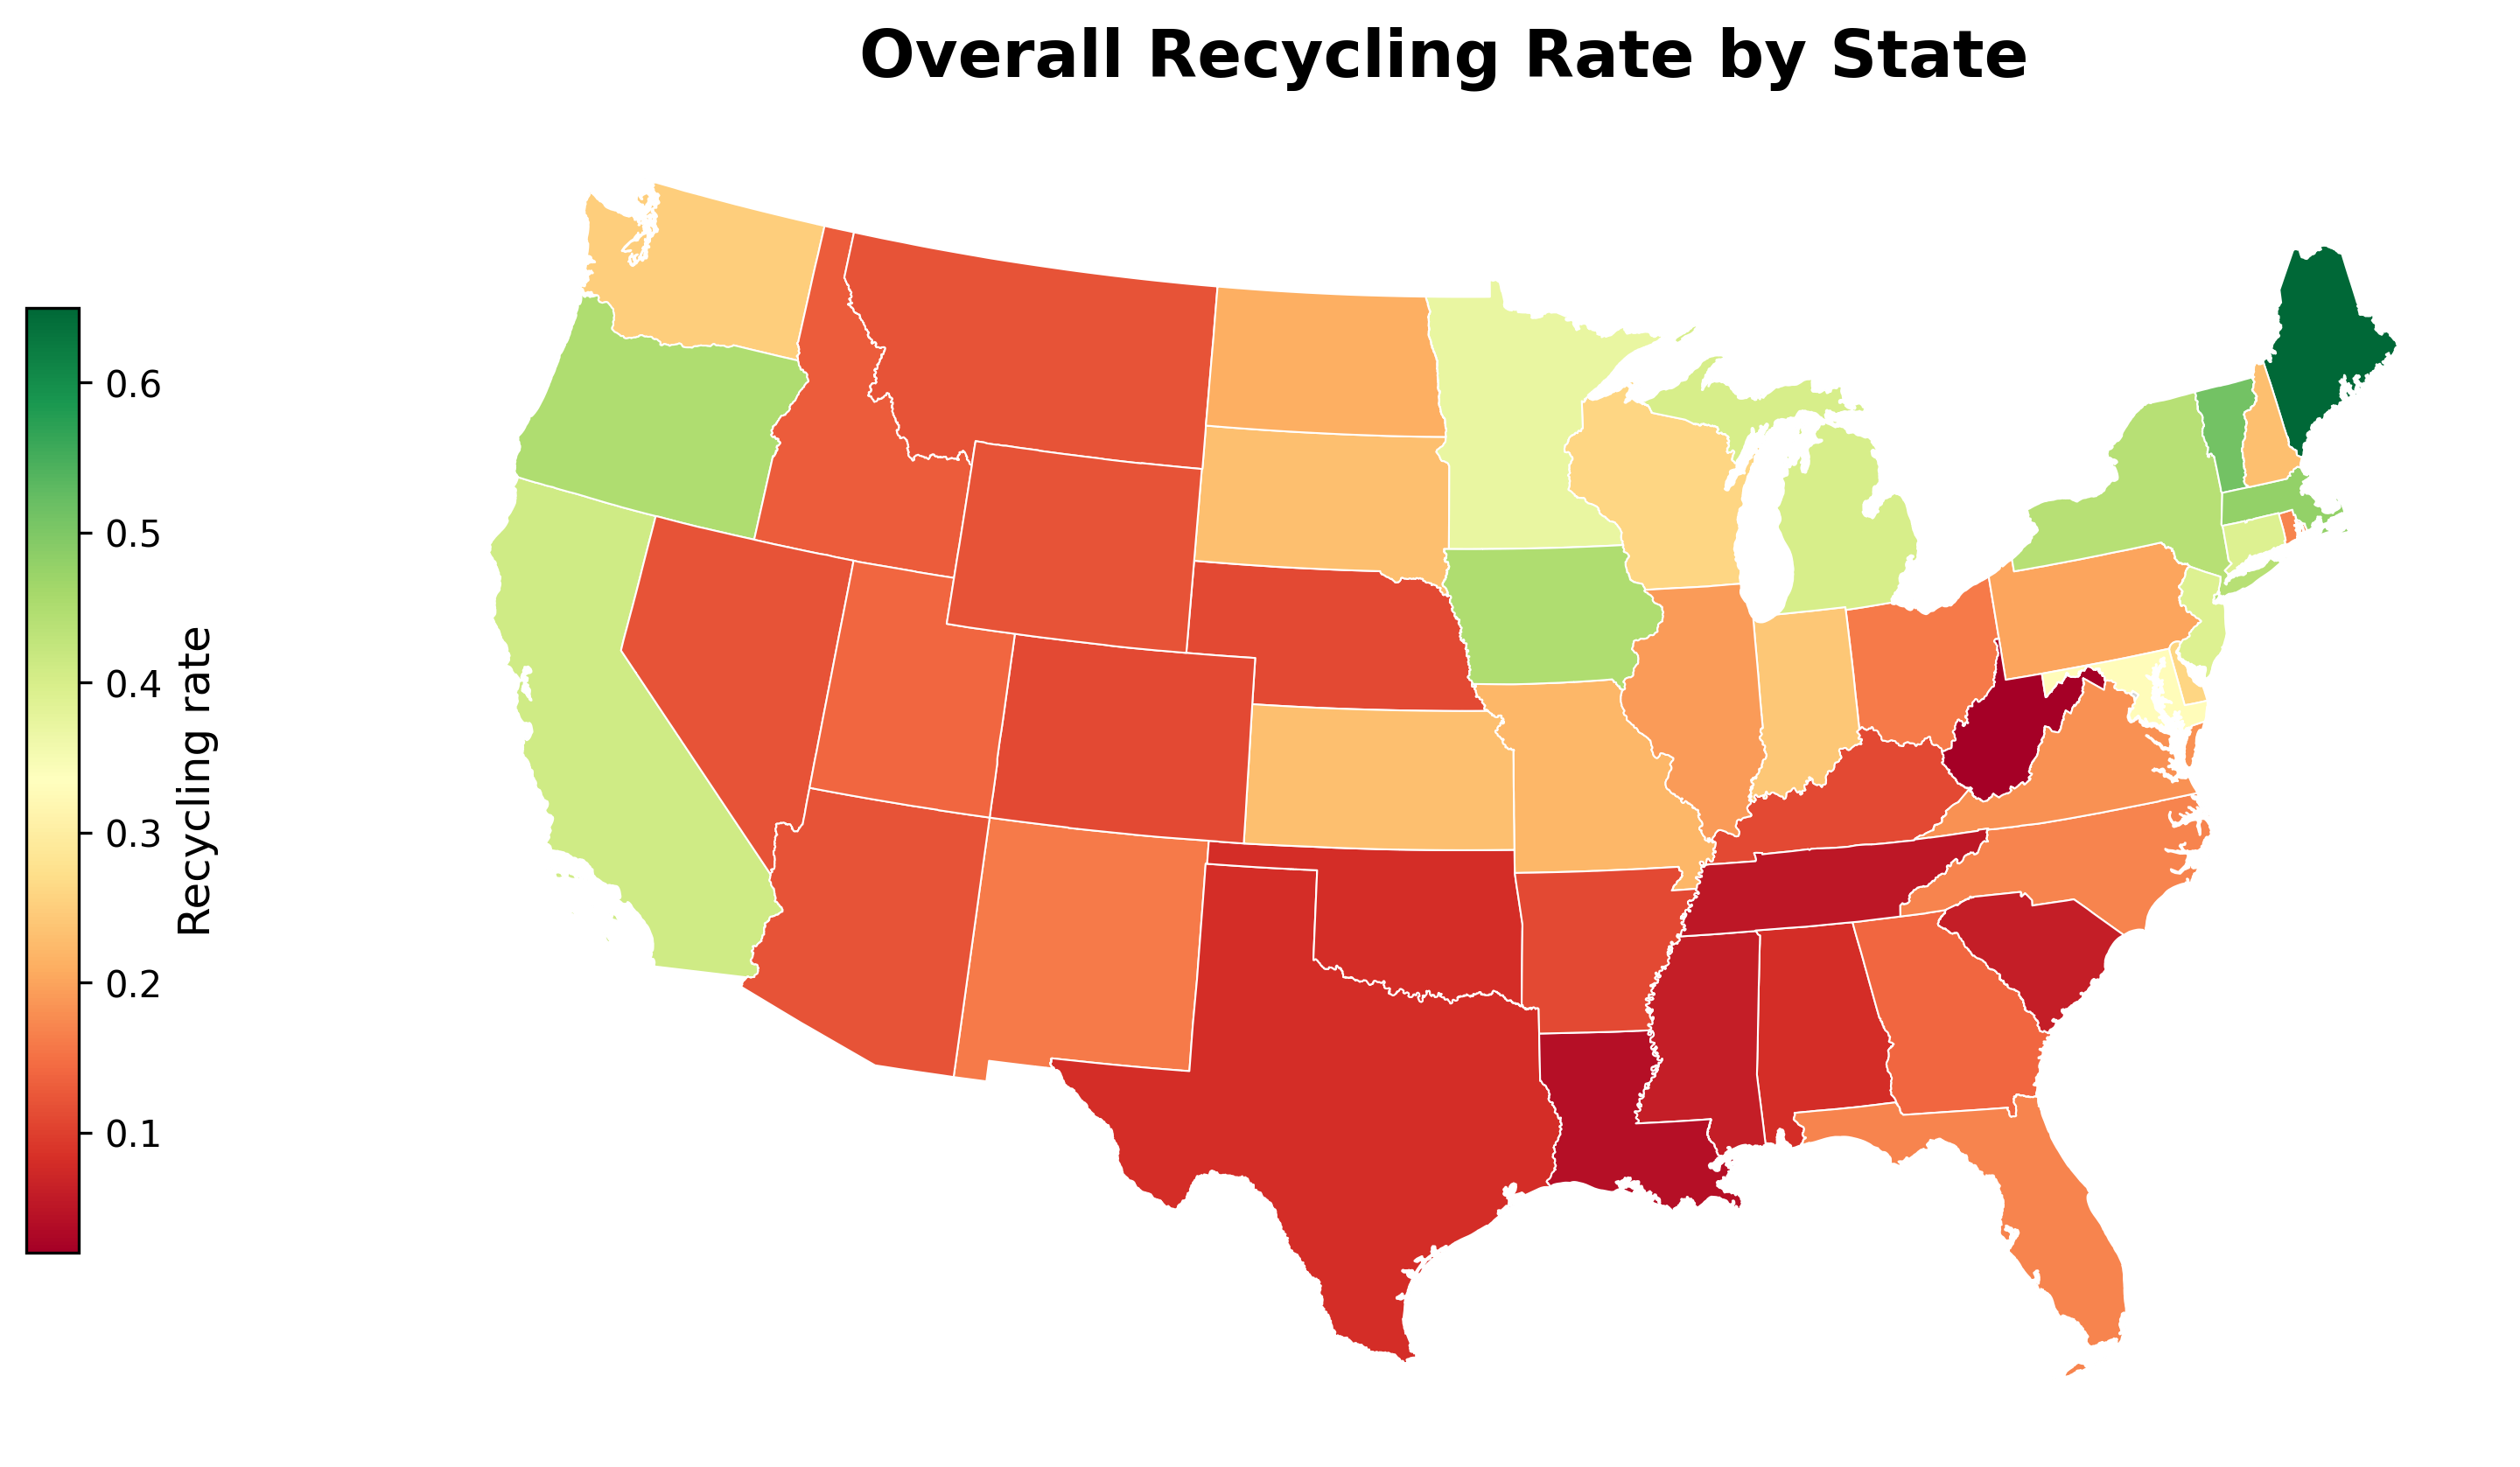

Saved figure to: fig2_material_means.png


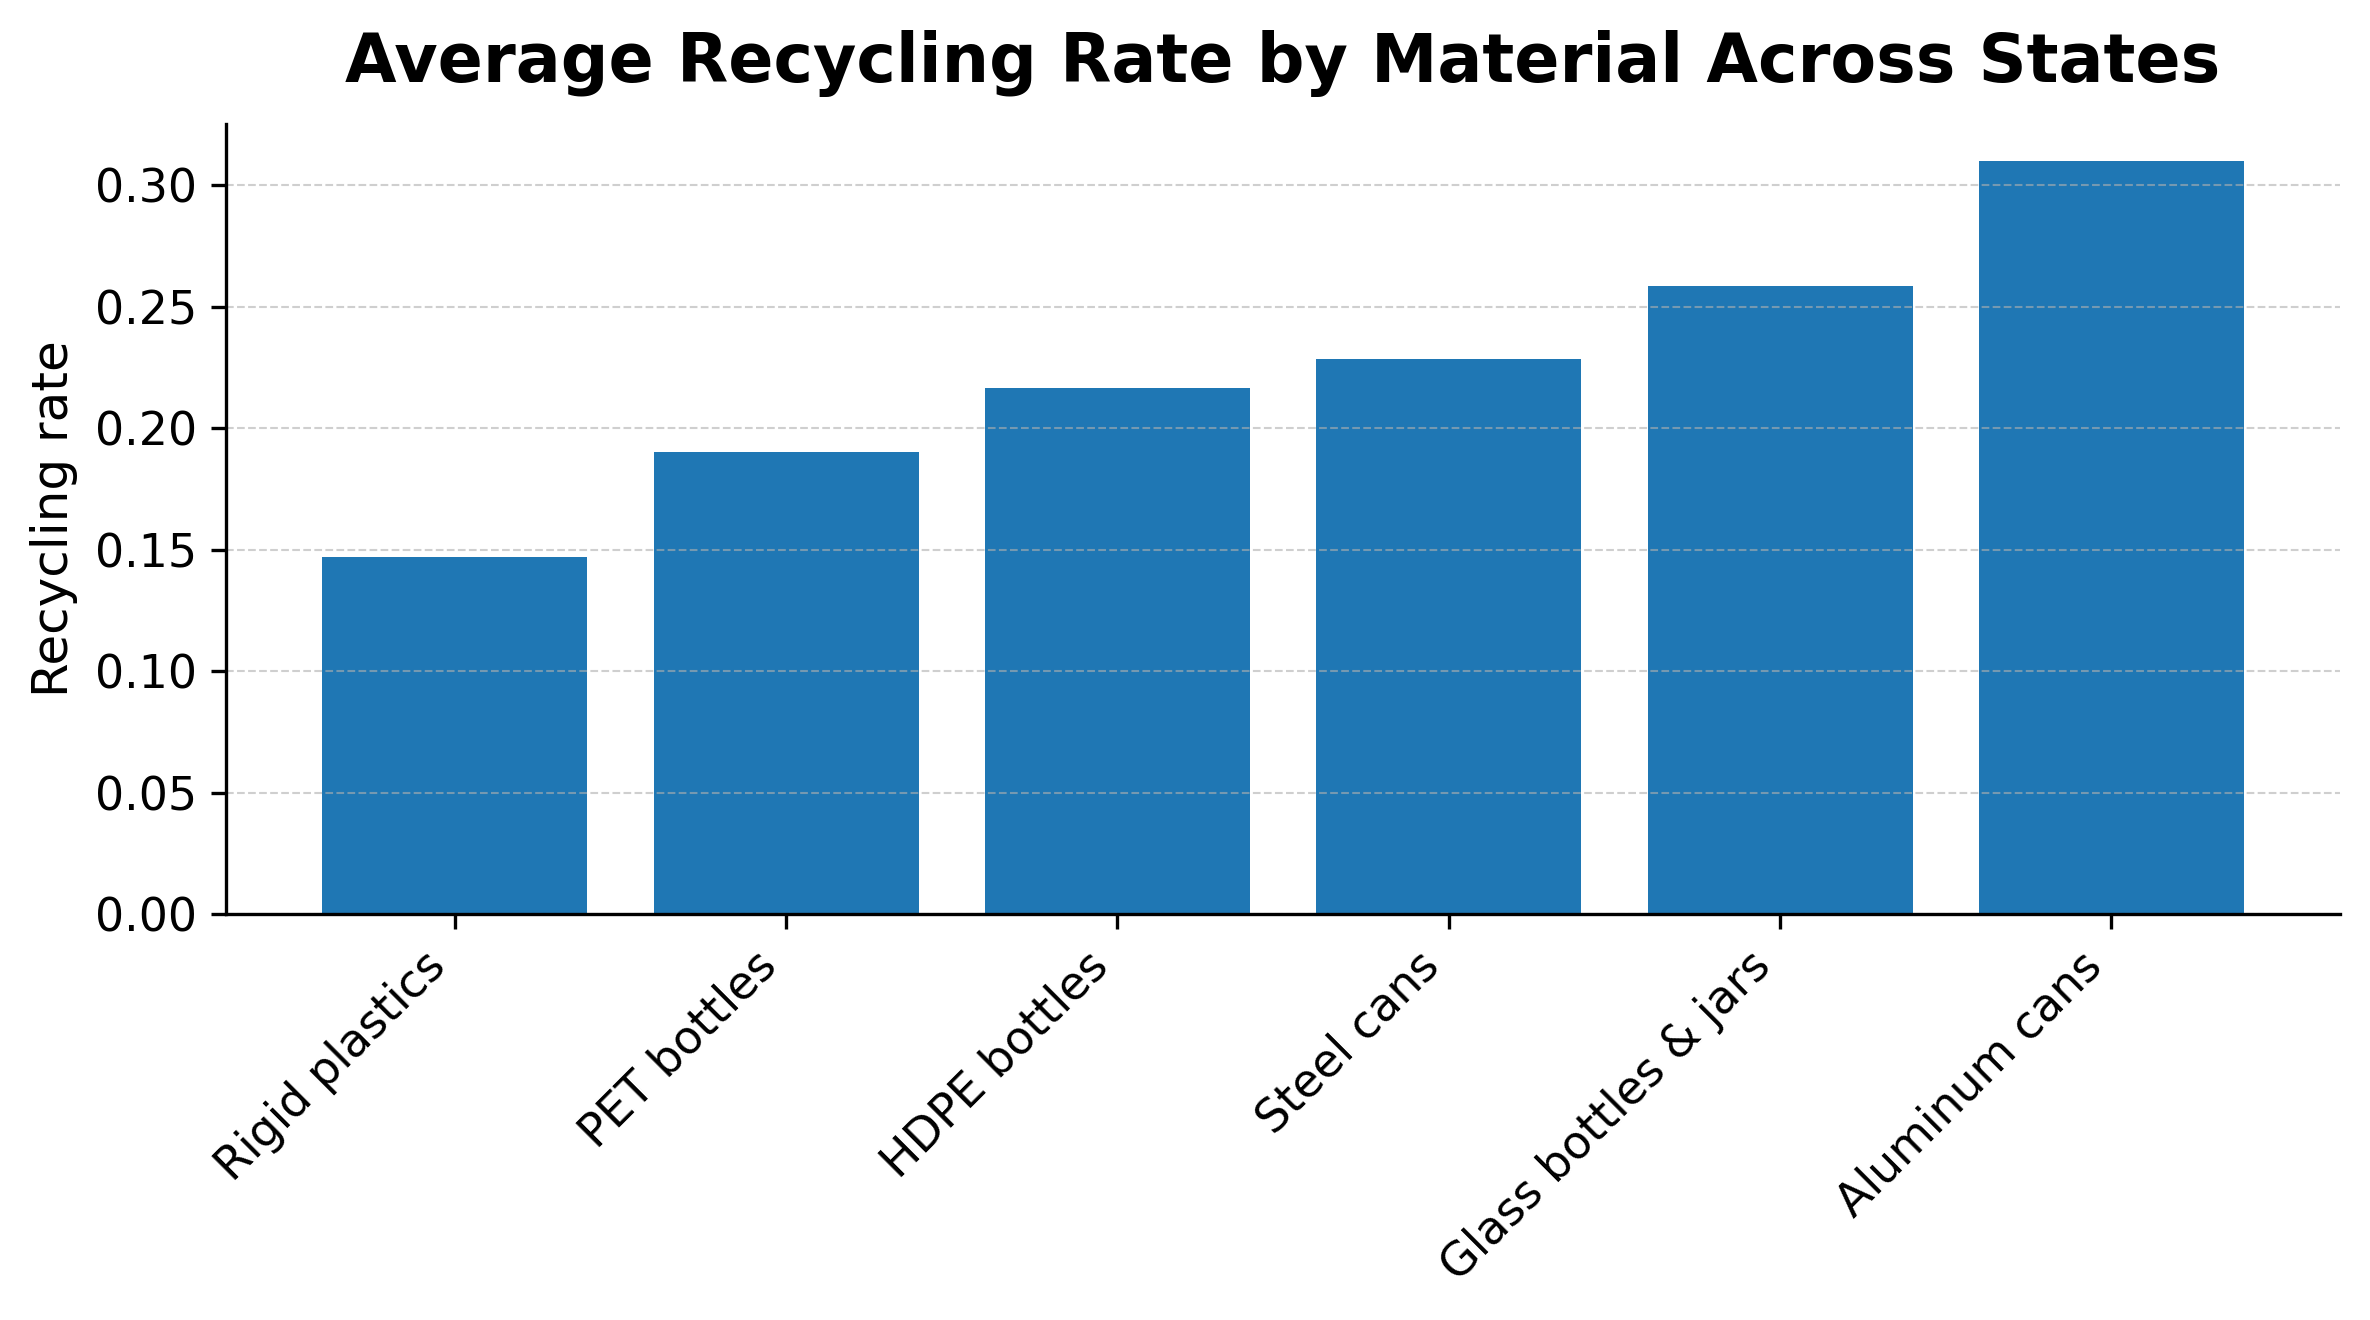

/tmp/ipython-input-111645162.py:181: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved figure to: fig3_container_deposit_boxplot.png


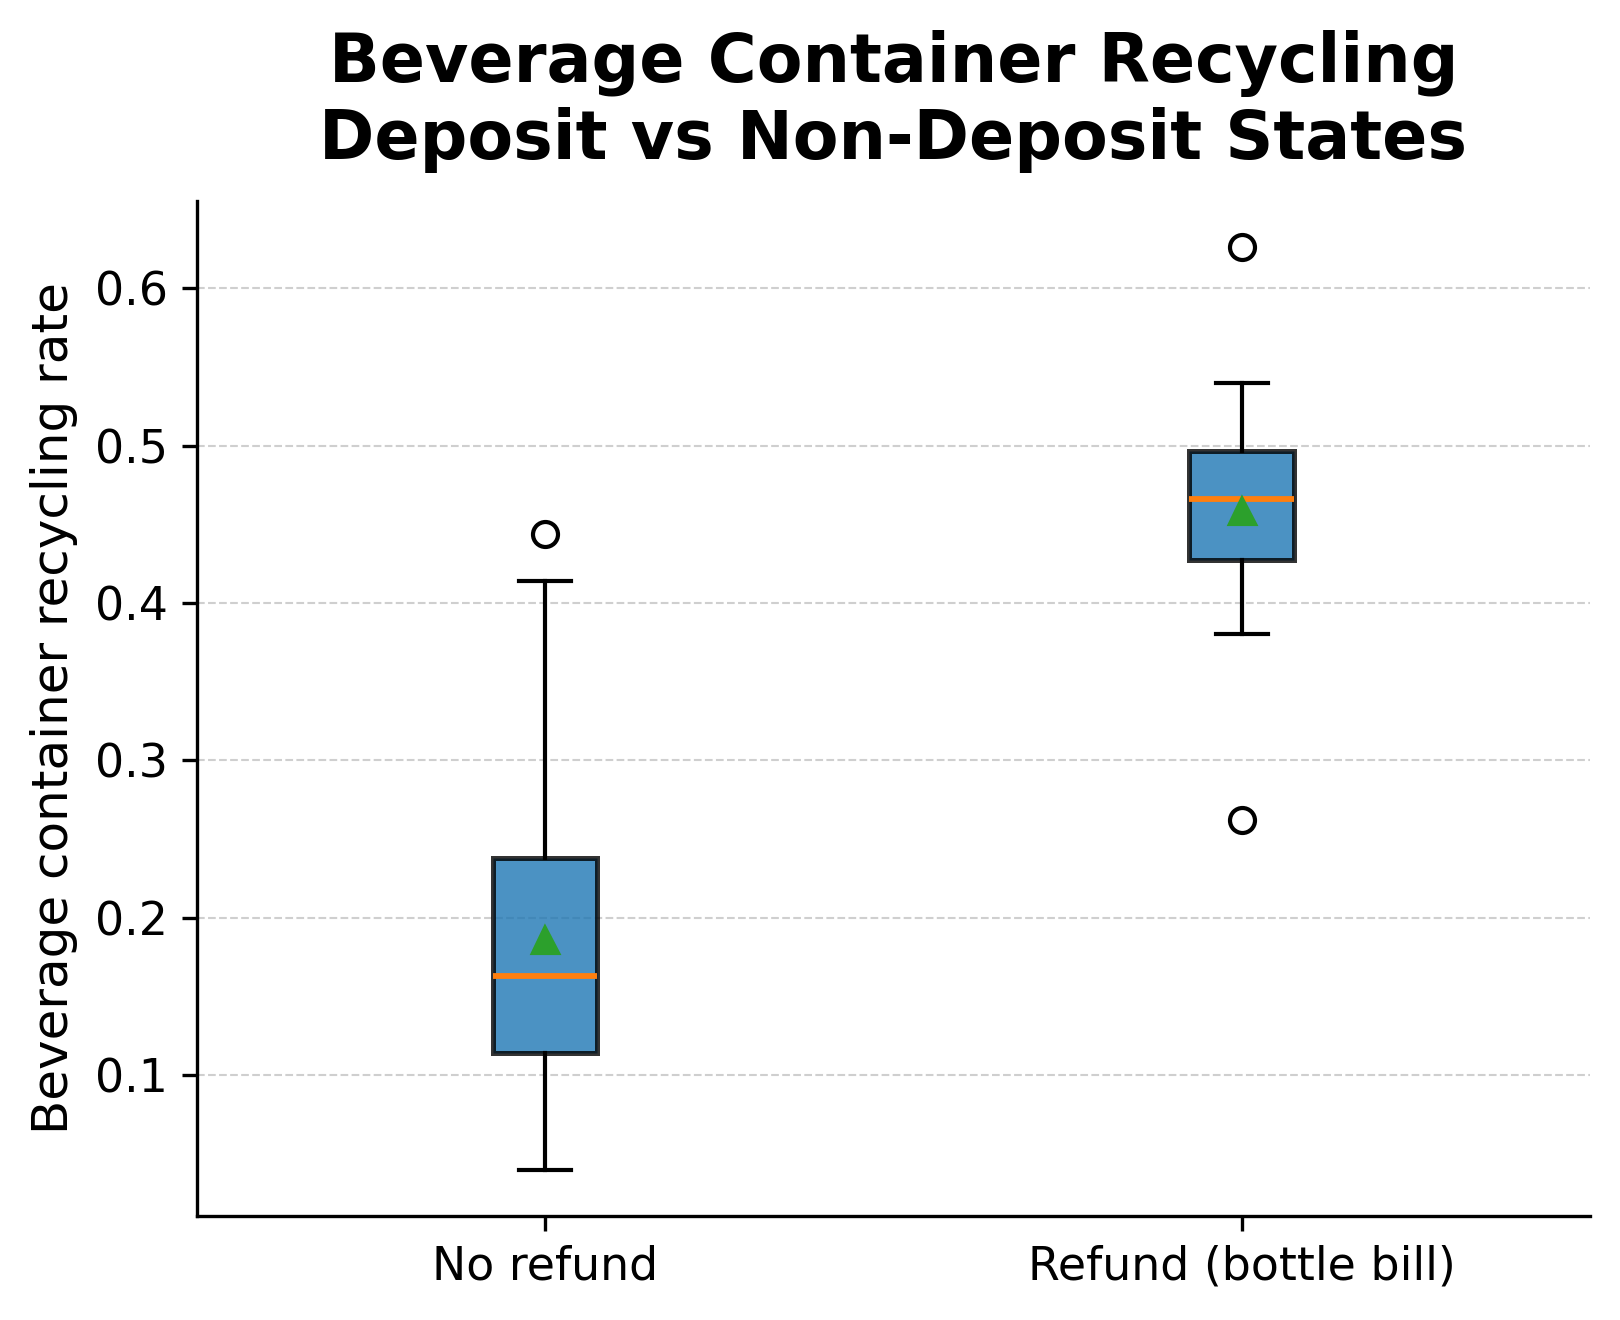

Saved figure to: fig4_1_mrf_vs_overall_recycling.png


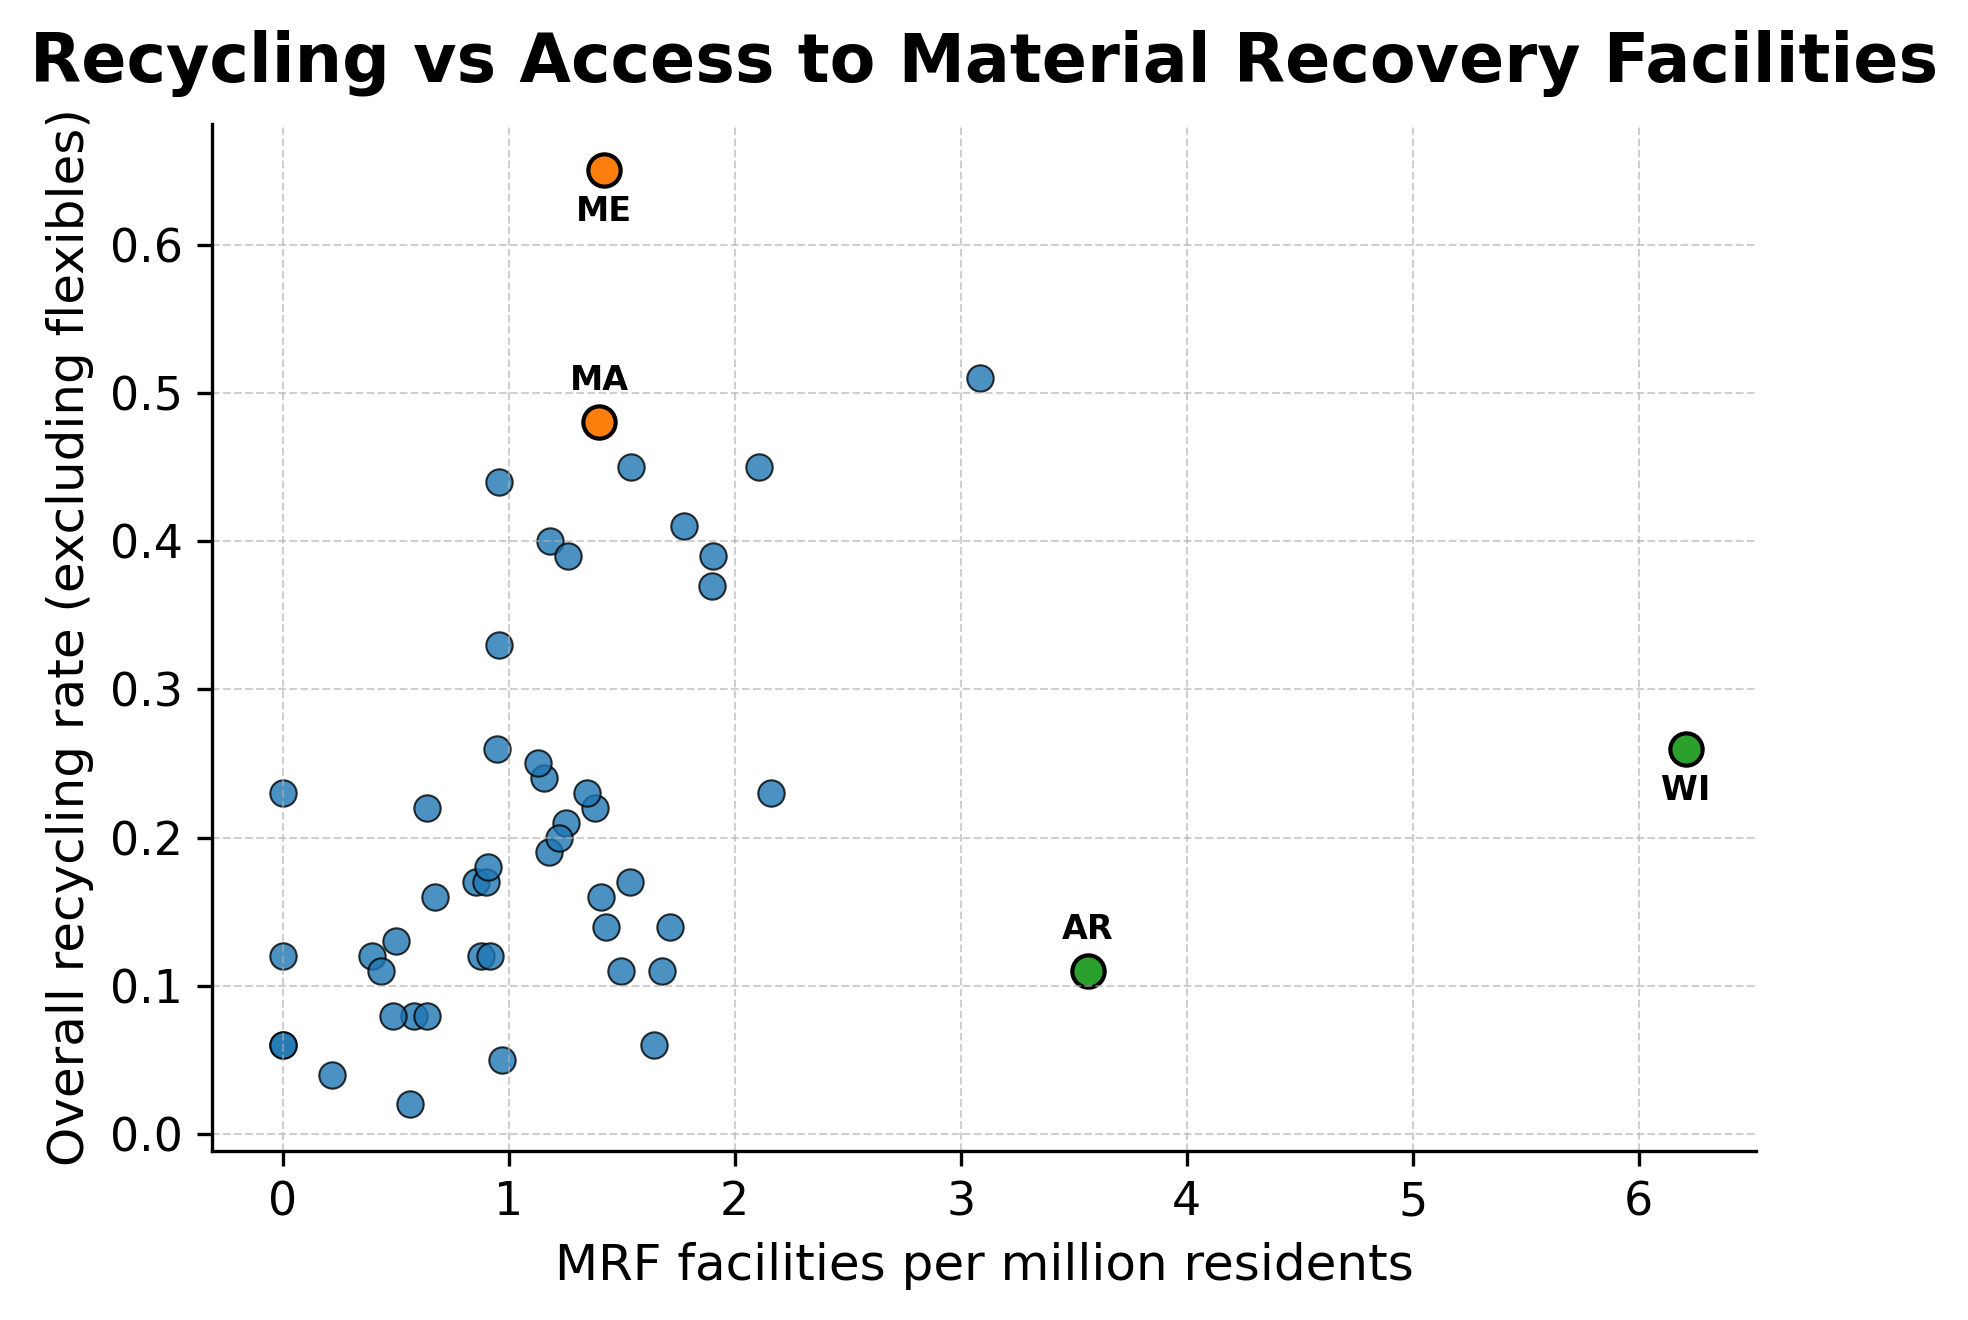

In [20]:
# Figure 1: Choropleth of overall recycling rate by state
plot_state_recycling_choropleth_matplotlib(
    merged,
    rate_col=recycling_rate_col,
    state_col="STATE_BALL",
    cmap="RdYlGn",
)

# Figure 2: Average recycling rate by material
plot_average_by_material(
    merged,
    materials,
    save_path="fig2_material_means.png",
)

# Figure 3: Deposit vs non-deposit boxplot
plot_deposit_boxplot_containers(
    merged,
    rate_col="CONTAINER_RECYCLING_RATE",
    deposit_col=deposit_col,
    save_path="fig3_container_deposit_boxplot.png",
)


# Figure 4: MRF facilities per million vs recycling rate
plot_scatter_vs_factor(
    merged,
    x_col="MRF_FACILITIES_PER_MILLION",
    y_col="RECYCLING_RATE_WITHOUT_FFP",
    x_label="MRF facilities per million residents",
    y_label="Overall recycling rate (excluding flexibles)",
    title="Recycling vs Access to Material Recovery Facilities",
    save_path="fig4_1_mrf_vs_overall_recycling.png",
    label_outliers=True,
    n_labels=2,
)



In [21]:
print("Merged columns:\n", merged.columns.tolist())

outcome_col   = "CONTAINER_RECYCLING_RATE"
deposit_col   = "RECYCLING_REFUND_STATE"

education_col = "PERCENT_BACHELORS_OR_HIGHER"
poverty_col   = "POVERTY_RATE_PCT"
income_col    = "MEDIAN_HOUSEHOLD_INCOME"

epr_col       = "EPR_PACKAGING"
bagban_col    = "PLASTIC_BAG_BAN"

party_col     = "GOVERNOR_PARTY"

mrf_col       = "MRF_FACILITIES_PER_MILLION"


Merged columns:
 ['Rank', 'STATE_BALL', 'RECYCLING_RATE_WITHOUT_FFP', 'ALUMINUM_CANS', 'STEEL_CANS', 'GLASS_BOTTLES_AND_JARS', 'PET_BOTTLES', 'HDPE_BOTTLES', 'RIGID_PLASTICS', 'CLOSED_LOOP_RECYCLING_WITHOUT_FFP', 'MATERIAL_VALUE_CAPTURED_USDM_WITHOUT_FFP', 'MATERIAL_VALUE_CAPTURED_PCT_WITHOUT_FFP', 'RECYCLING_REFUND_STATE', 'STATE_KEY', 'STATE_FAC', 'MRF_FACILITIES', 'TRANSFER_FACILITIES', 'METALS_RECYCLING_FACILITIES', 'GLASS_RECYCLING_FACILITY', 'PLASTIC_RECYCLING_FACILITIES', 'PAPER_RECYCLING_FACILITIES', 'ELECTRONICS_RECYCLING_FACILITIES', 'NUMBER_OF_SECONDARY_GLASS_PROCESSORS', 'EPR_PACKAGING', 'EWASTE_LAW', 'BOTTLE_BILL', 'PLASTIC_BAG_BAN', 'ENVIRONMENTAL_AND_NATURAL_RESOURCES_DEPARTMENT_SPENDING_2015', 'MEDIAN_HOUSEHOLD_INCOME', 'PARTY_OF_GOVERNOR_MAYOR_FOR_DC', 'POPULATION', 'POPULATION_DENSITY_2020_PER_SQ_MILE', 'PERCENT_BACHELORS_OR_HIGHER', 'PERCENT_ADVANCED_DEGREE', 'UNEMPLOYMENT_AUG2025', 'POVERTY_RATE_PCT', 'MRF_FACILITIES_PER_MILLION', 'ENV_SPENDING_PER_CAPITA', 'CONTAIN

In [22]:
# Container recycling - deposit-only regression
df_dep = merged[[outcome_col, deposit_col]].dropna().copy()

df_dep[deposit_col] = df_dep[deposit_col].astype(int)

X_dep = sm.add_constant(df_dep[deposit_col])
y_dep = df_dep[outcome_col]

model_dep = sm.OLS(y_dep, X_dep).fit()
print(model_dep.summary())

dep_coef = model_dep.params[deposit_col] * 100
ci_low, ci_high = model_dep.conf_int().loc[deposit_col] * 100

print()
print("=== Deposit-only model interpretation ===")
print(f"Estimated effect of having a deposit law: {dep_coef:.1f} percentage points")
print(f"95% CI: [{ci_low:.1f}, {ci_high:.1f}] percentage points")
print(f"R-squared: {model_dep.rsquared:.3f}")


                               OLS Regression Results                               
Dep. Variable:     CONTAINER_RECYCLING_RATE   R-squared:                       0.555
Model:                                  OLS   Adj. R-squared:                  0.546
Method:                       Least Squares   F-statistic:                     59.81
Date:                      Tue, 16 Dec 2025   Prob (F-statistic):           5.57e-10
Time:                              20:40:20   Log-Likelihood:                 45.393
No. Observations:                        50   AIC:                            -86.79
Df Residuals:                            48   BIC:                            -82.96
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [23]:
# Main model: containers - policy + infra + socio-econ + politics
df_main = merged.copy()

for col in [deposit_col, epr_col, bagban_col]:
    if col in df_main.columns and df_main[col].dtype == bool:
        df_main[col] = df_main[col].astype(int)

party_dummy_col = None
if party_col in df_main.columns:
    df_main["PARTY_DEM"] = (df_main[party_col].astype(str).str.upper() == "D").astype(int)
    party_dummy_col = "PARTY_DEM"

desired_predictors = [
    deposit_col,
    epr_col,
    bagban_col,
    mrf_col,
    education_col,
    poverty_col,
    income_col,
]

if party_dummy_col is not None:
    desired_predictors.append(party_dummy_col)

predictors_main = [p for p in desired_predictors if p in df_main.columns]

missing = [p for p in desired_predictors if p not in df_main.columns]
print("Using predictors in main model:", predictors_main)
if missing:
    print("WARNING: These predictors were not found and will be skipped:", missing)

cols_needed = [outcome_col] + predictors_main
df_main_clean = df_main[cols_needed].dropna().copy()
print("Main model sample size:", df_main_clean.shape[0])

X_main = sm.add_constant(df_main_clean[predictors_main])
y_main = df_main_clean[outcome_col]

model_main = sm.OLS(y_main, X_main).fit()
print(model_main.summary())


Using predictors in main model: ['RECYCLING_REFUND_STATE', 'EPR_PACKAGING', 'PLASTIC_BAG_BAN', 'MRF_FACILITIES_PER_MILLION', 'PERCENT_BACHELORS_OR_HIGHER', 'POVERTY_RATE_PCT', 'MEDIAN_HOUSEHOLD_INCOME']
Main model sample size: 50
                               OLS Regression Results                               
Dep. Variable:     CONTAINER_RECYCLING_RATE   R-squared:                       0.765
Model:                                  OLS   Adj. R-squared:                  0.726
Method:                       Least Squares   F-statistic:                     19.52
Date:                      Tue, 16 Dec 2025   Prob (F-statistic):           2.45e-11
Time:                              20:40:20   Log-Likelihood:                 61.359
No. Observations:                        50   AIC:                            -106.7
Df Residuals:                            42   BIC:                            -91.42
Df Model:                                 7                                         
Covar

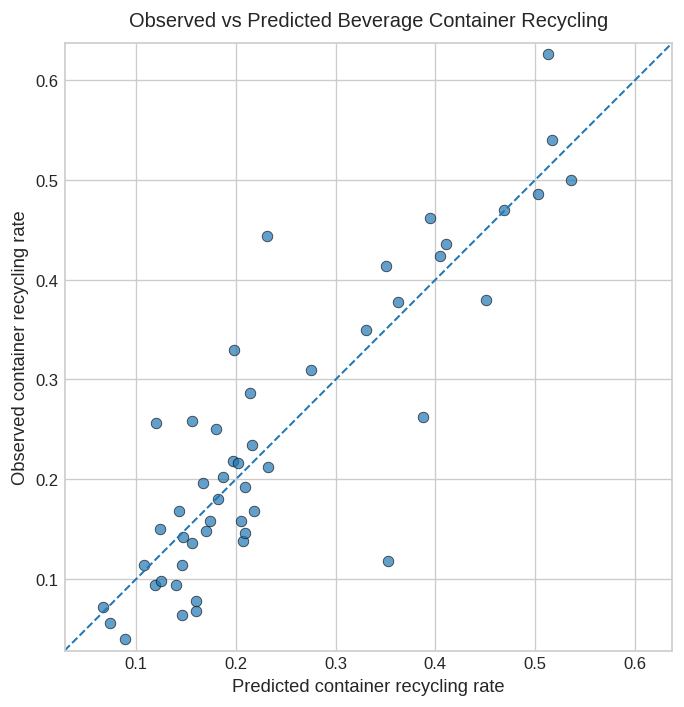

State-like columns in df_main: ['STATE_BALL', 'RECYCLING_REFUND_STATE', 'STATE_KEY', 'STATE_FAC']
Using state name column: STATE_BALL


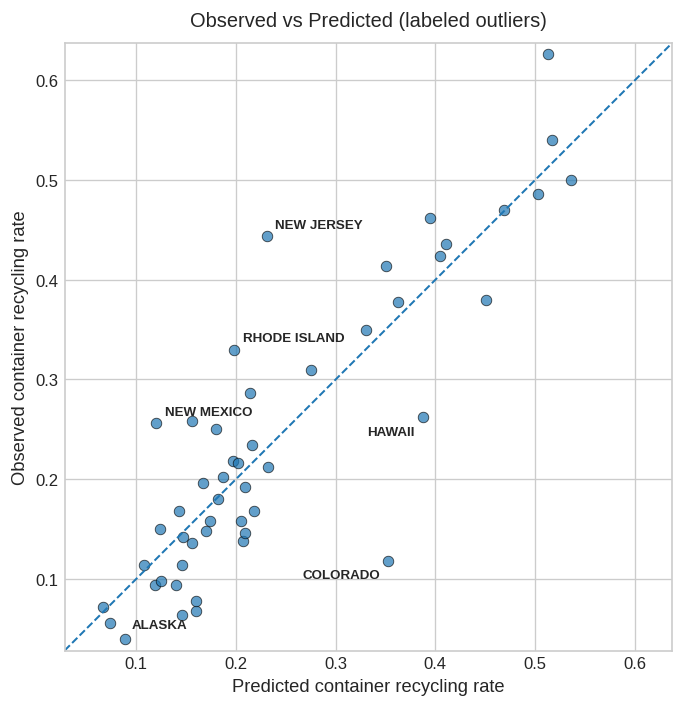

In [24]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# Predicted vs observed scatter for the main model
df_main_clean["PRED_MAIN"] = model_main.predict(X_main)

fig, ax = plt.subplots(figsize=(6, 6), dpi=120)

ax.scatter(
    df_main_clean["PRED_MAIN"],
    df_main_clean[outcome_col],
    s=40,
    alpha=0.7,
    edgecolor="black",
    linewidth=0.5,
)

min_val = min(df_main_clean["PRED_MAIN"].min(), df_main_clean[outcome_col].min())
max_val = max(df_main_clean["PRED_MAIN"].max(), df_main_clean[outcome_col].max())
padding = 0.02 * (max_val - min_val)
line_min, line_max = min_val - padding, max_val + padding

ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    linewidth=1.2,
)

ax.set_xlim(line_min, line_max)
ax.set_ylim(line_min, line_max)

ax.set_aspect("equal", "box")

ax.set_xlabel("Predicted container recycling rate", fontsize=11)
ax.set_ylabel("Observed container recycling rate", fontsize=11)
ax.set_title("Observed vs Predicted Beverage Container Recycling", fontsize=12, pad=10)

fig.tight_layout()
plt.show()


# Labeled outliers plot
state_cols = [c for c in df_main.columns if "STATE" in c.upper()]
print("State-like columns in df_main:", state_cols)

if state_cols:
    state_col = state_cols[0]
    print("Using state name column:", state_col)

    df_scatter = df_main_clean.copy()
    df_scatter[state_col] = df_main.loc[df_scatter.index, state_col]

    df_scatter["RESID"] = df_scatter[outcome_col] - df_scatter["PRED_MAIN"]
    top_over  = df_scatter.sort_values("RESID", ascending=False).head(3)
    top_under = df_scatter.sort_values("RESID", ascending=True).head(3)

    fig, ax = plt.subplots(figsize=(6, 6), dpi=120)

    ax.scatter(
        df_scatter["PRED_MAIN"],
        df_scatter[outcome_col],
        s=40,
        alpha=0.7,
        edgecolor="black",
        linewidth=0.5,
    )

    ax.plot(
        [line_min, line_max],
        [line_min, line_max],
        linestyle="--",
        linewidth=1.2,
    )

    for _, row in top_over.iterrows():
        ax.annotate(
            str(row[state_col]),
            (row["PRED_MAIN"], row[outcome_col]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            weight="bold",
        )

    for _, row in top_under.iterrows():
        ax.annotate(
            str(row[state_col]),
            (row["PRED_MAIN"], row[outcome_col]),
            xytext=(-5, -5),
            textcoords="offset points",
            ha="right",
            va="top",
            fontsize=8,
            weight="bold",
        )

    ax.set_xlim(line_min, line_max)
    ax.set_ylim(line_min, line_max)
    ax.set_aspect("equal", "box")

    ax.set_xlabel("Predicted container recycling rate", fontsize=11)
    ax.set_ylabel("Observed container recycling rate", fontsize=11)
    ax.set_title("Observed vs Predicted (labeled outliers)", fontsize=12, pad=10)

    fig.tight_layout()
    plt.show()

else:
    print("No state-name column found in df_main; skipping labeled outliers plot.")


Saved figure to: fig_policy_effects.png


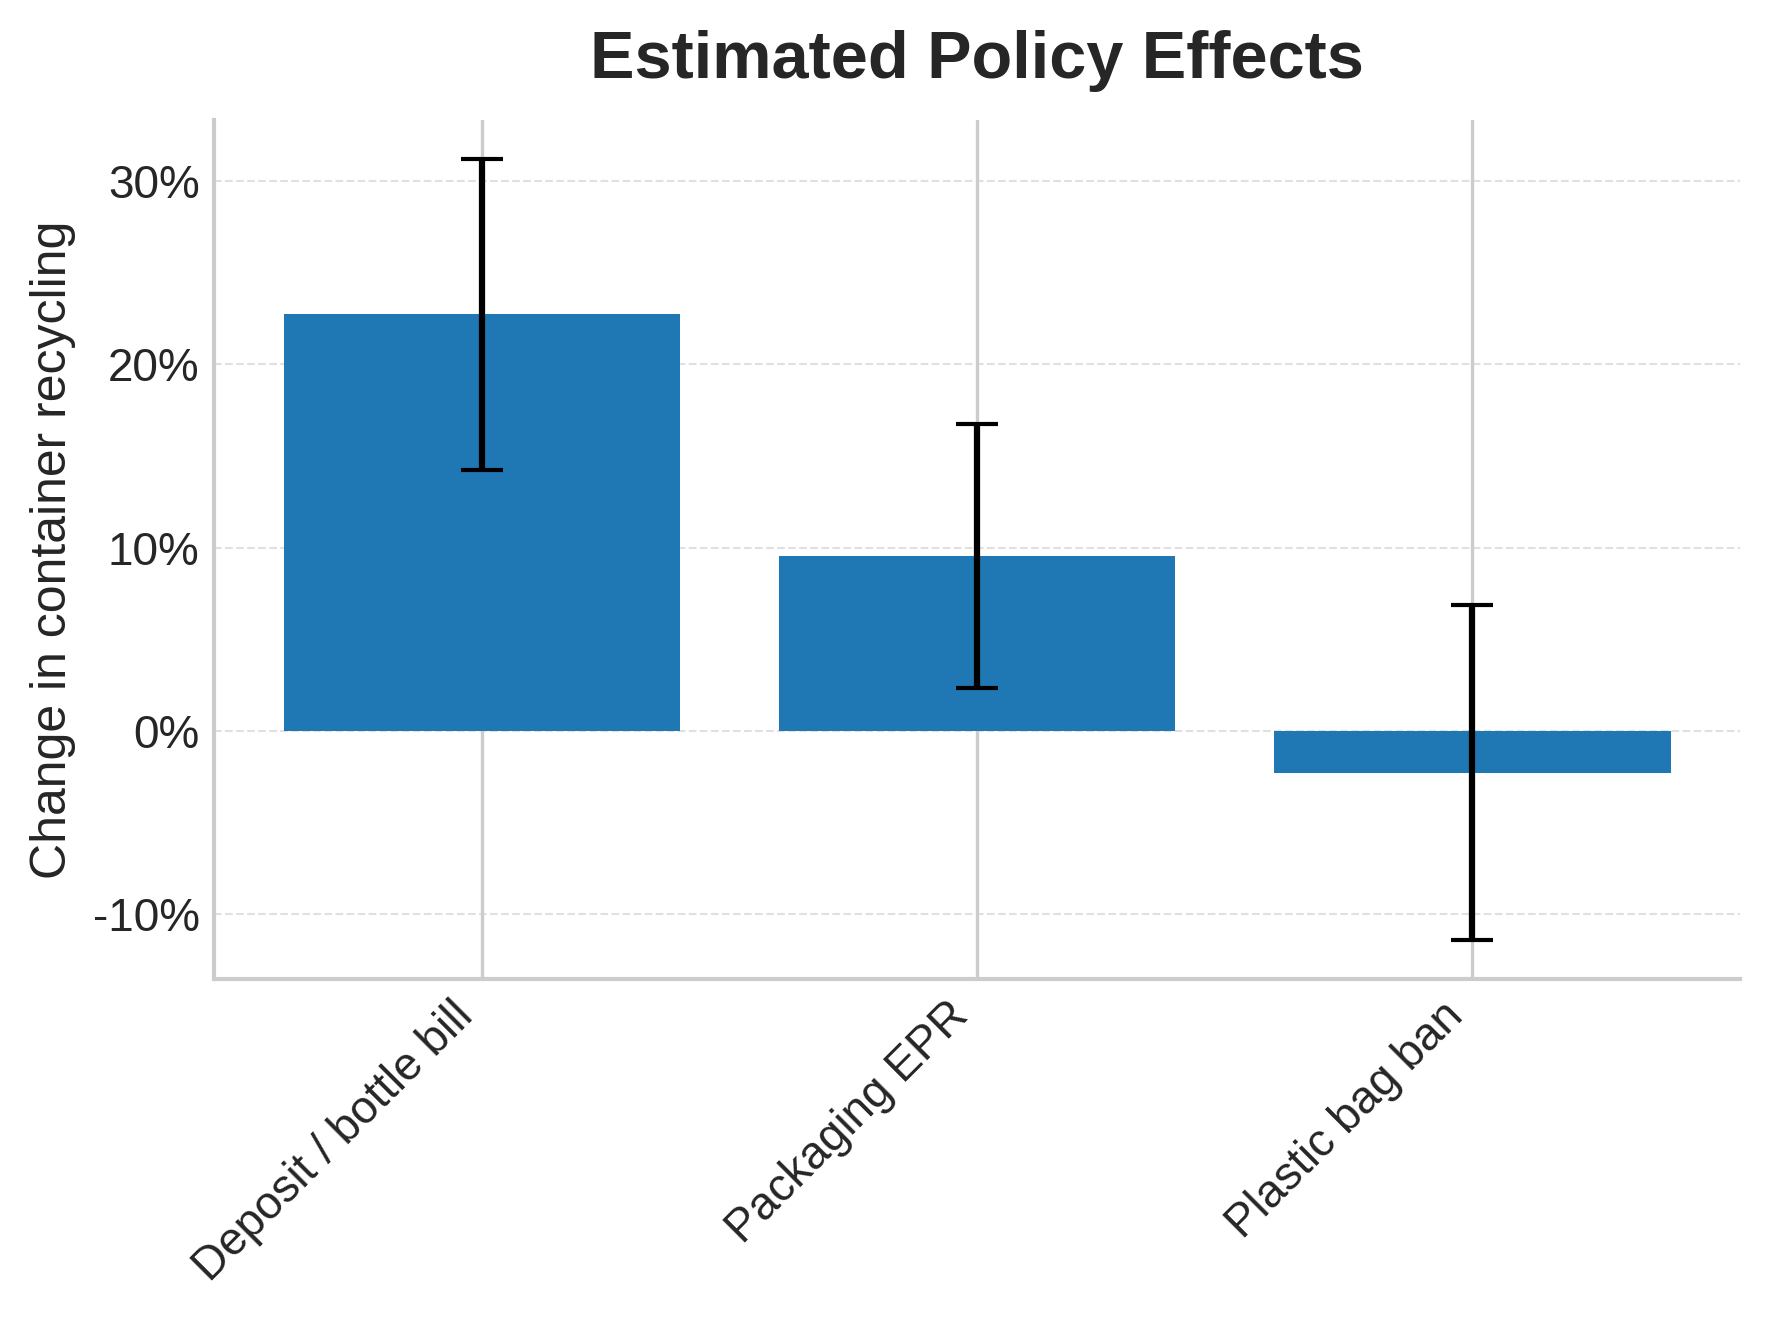

In [25]:
# Policy effect bar chart

policy_vars = [deposit_col, epr_col, bagban_col]
policy_vars = [v for v in policy_vars if v in model_main.params.index]

effects_pct = model_main.params[policy_vars] * 100
cis_pct = model_main.conf_int().loc[policy_vars] * 100

policy_effects = pd.DataFrame({
    "effect": effects_pct,
    "ci_low": cis_pct[0],
    "ci_high": cis_pct[1],
})

policy_label_map = {
    deposit_col: "Deposit / bottle bill",
    epr_col: "Packaging EPR",
    bagban_col: "Plastic bag ban",
}
x_labels = [policy_label_map.get(v, v) for v in policy_vars]

save_path = "fig_policy_effects.png"

fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)
fig.patch.set_alpha(0)
ax.set_facecolor("none")

x = np.arange(len(policy_vars))
heights = policy_effects["effect"].values

yerr = np.vstack([
    heights - policy_effects["ci_low"].values,
    policy_effects["ci_high"].values - heights,
])

bars = ax.bar(
    x,
    heights,
    yerr=yerr,
    capsize=5,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Change in container recycling", fontsize=12)
ax.set_title("Estimated Policy Effects", fontsize=16, pad=10, fontweight="bold")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0f}%")
)
ax.tick_params(axis="y", labelsize=11)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

plt.tight_layout()

if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
    print(f"Saved figure to: {save_path}")

plt.show()


In [26]:
pop_col            = "POPULATION"
mrf_raw_col        = "MRF_FACILITIES"
env_spend_raw_col  = "ENVIRONMENTAL_AND_NATURAL_RESOURCES_DEPARTMENT_SPENDING_2015"
overall_rate_col   = "RECYCLING_RATE_WITHOUT_FFP"

if "MRF_FACILITIES_PER_MILLION" not in merged.columns:
    merged["MRF_FACILITIES_PER_MILLION"] = merged[mrf_raw_col] / (merged[pop_col] / 1_000_000)

if "ENV_SPENDING_PER_CAPITA" not in merged.columns:
    merged["ENV_SPENDING_PER_CAPITA"] = merged[env_spend_raw_col] * 1e6 / merged[pop_col]

print("Key columns ready?")
for c in ["MRF_FACILITIES_PER_MILLION", "ENV_SPENDING_PER_CAPITA", overall_rate_col]:
    print(f" - {c}: {c in merged.columns}")


Key columns ready?
 - MRF_FACILITIES_PER_MILLION: True
 - ENV_SPENDING_PER_CAPITA: True
 - RECYCLING_RATE_WITHOUT_FFP: True


In [27]:
def plot_scatter_vs_factor(
    df,
    x_col,
    y_col,
    x_label=None,
    y_label=None,
    title=None,
    save_path=None,
    label_outliers=False,
    n_labels=3,
):
    """
    Scatter plot of overall recycling vs a factor.
    """
    data = df[[x_col, y_col]].dropna().copy()

    plt.figure(figsize=(5, 4))
    plt.scatter(data[x_col], data[y_col])
    plt.xlabel(x_label if x_label else x_col)
    plt.ylabel(y_label if y_label else y_col)
    plt.title(title if title else f"{y_col} vs {x_col}")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")

    plt.show()

    if not label_outliers:
        return

    state_cols = [c for c in df.columns if "STATE" in c.upper()]
    if not state_cols:
        print("No state name column found; skipping labeled version.")
        return
    state_col = state_cols[0]

    data = df[[x_col, y_col, state_col]].dropna().copy()

    X = sm.add_constant(data[[x_col]])
    model = sm.OLS(data[y_col], X).fit()
    data["PRED"] = model.predict(X)
    data["RESID"] = data[y_col] - data["PRED"]

    top_over  = data.sort_values("RESID", ascending=False).head(n_labels)
    top_under = data.sort_values("RESID", ascending=True).head(n_labels)

    plt.figure(figsize=(5, 4))
    plt.scatter(data[x_col], data[y_col])
    plt.xlabel(x_label if x_label else x_col)
    plt.ylabel(y_label if y_label else y_col)
    plt.title(title if title else f"{y_col} vs {x_col}")

    for _, row in top_over.iterrows():
        plt.text(row[x_col], row[y_col], str(row[state_col]),
                 fontsize=8, ha="left", va="bottom")
    for _, row in top_under.iterrows():
        plt.text(row[x_col], row[y_col], str(row[state_col]),
                 fontsize=8, ha="right", va="top")

    plt.tight_layout()
    if save_path:
        labeled_path = save_path.replace(".png", "_labeled.png")
        plt.savefig(labeled_path, dpi=300, bbox_inches="tight")
        print(f"Saved labeled figure to: {labeled_path}")
    plt.show()


Saved figure to: fig4_1_mrf_vs_overall_recycling.png


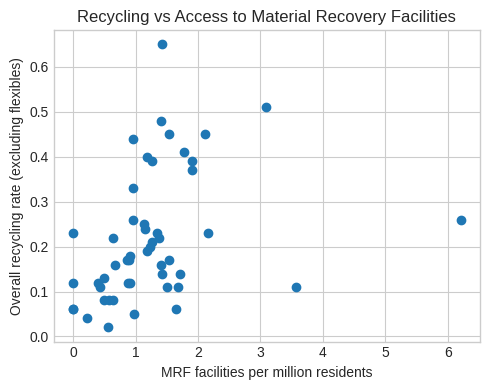

Saved labeled figure to: fig4_1_mrf_vs_overall_recycling_labeled.png


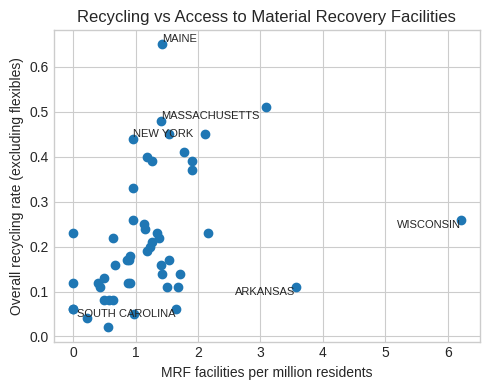

In [28]:
plot_scatter_vs_factor(
    merged,
    x_col="MRF_FACILITIES_PER_MILLION",
    y_col="RECYCLING_RATE_WITHOUT_FFP",
    x_label="MRF facilities per million residents",
    y_label="Overall recycling rate (excluding flexibles)",
    title="Recycling vs Access to Material Recovery Facilities",
    save_path="fig4_1_mrf_vs_overall_recycling.png",
    label_outliers=True,   # set to False if you don't want labels
    n_labels=3,
)


Saved figure to: fig4_2_env_spending_vs_overall_recycling.png


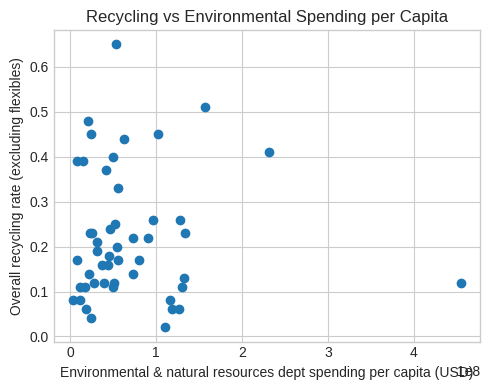

In [29]:
plot_scatter_vs_factor(
    merged,
    x_col="ENV_SPENDING_PER_CAPITA",
    y_col="RECYCLING_RATE_WITHOUT_FFP",
    x_label="Environmental & natural resources dept spending per capita (USD)",
    y_label="Overall recycling rate (excluding flexibles)",
    title="Recycling vs Environmental Spending per Capita",
    save_path="fig4_2_env_spending_vs_overall_recycling.png",
    label_outliers=False,  # turn on if you want labeled outliers
)


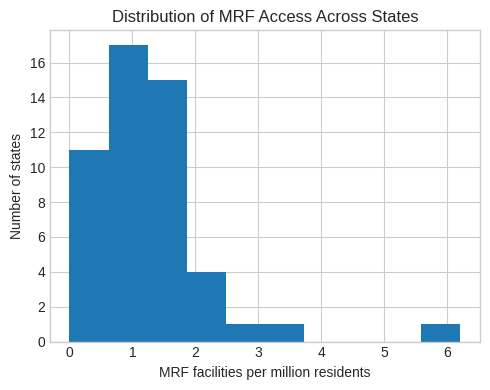

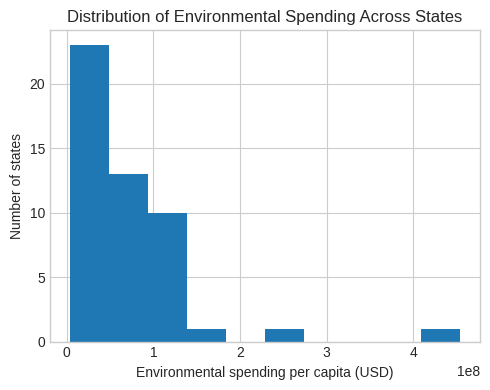

In [30]:
plt.figure(figsize=(5, 4))
merged["MRF_FACILITIES_PER_MILLION"].dropna().hist(bins=10)
plt.xlabel("MRF facilities per million residents")
plt.ylabel("Number of states")
plt.title("Distribution of MRF Access Across States")
plt.tight_layout()
plt.savefig("fig4_3_hist_mrf_per_million.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(5, 4))
merged["ENV_SPENDING_PER_CAPITA"].dropna().hist(bins=10)
plt.xlabel("Environmental spending per capita (USD)")
plt.ylabel("Number of states")
plt.title("Distribution of Environmental Spending Across States")
plt.tight_layout()
plt.savefig("fig4_4_hist_env_spending_per_capita.png", dpi=300, bbox_inches="tight")
plt.show()


In [31]:
overall_rate_col = "RECYCLING_RATE_WITHOUT_FFP"

education_col = "PERCENT_BACHELORS_OR_HIGHER"
poverty_col   = "POVERTY_RATE_PCT"
income_col    = "MEDIAN_HOUSEHOLD_INCOME"
party_col     = "PARTY_OF_GOVERNOR_MAYOR_FOR_DC"

print("Check columns exist:")
for c in [overall_rate_col, education_col, poverty_col, income_col, party_col]:
    print(f" - {c}: {c in merged.columns}")

if party_col in merged.columns:
    print("\nUnique values in party_col:")
    print(merged[party_col].unique())


Check columns exist:
 - RECYCLING_RATE_WITHOUT_FFP: True
 - PERCENT_BACHELORS_OR_HIGHER: True
 - POVERTY_RATE_PCT: True
 - MEDIAN_HOUSEHOLD_INCOME: True
 - PARTY_OF_GOVERNOR_MAYOR_FOR_DC: True

Unique values in party_col:
['R' 'D']


In [32]:
cols = [overall_rate_col, education_col, poverty_col, income_col]
corr_df = merged[cols].dropna().corr()
print("Correlation matrix:")
print(corr_df)

r_edu = corr_df.loc[overall_rate_col, education_col]
r_pov = corr_df.loc[overall_rate_col, poverty_col]
r_inc = corr_df.loc[overall_rate_col, income_col]

print("\nKey correlations with overall recycling:")
print(f" - Education vs recycling: r = {r_edu:.3f}")
print(f" - Poverty vs recycling:   r = {r_pov:.3f}")
print(f" - Income vs recycling:    r = {r_inc:.3f}")


Correlation matrix:
                             RECYCLING_RATE_WITHOUT_FFP  \
RECYCLING_RATE_WITHOUT_FFP                     1.000000   
PERCENT_BACHELORS_OR_HIGHER                    0.577477   
POVERTY_RATE_PCT                              -0.485665   
MEDIAN_HOUSEHOLD_INCOME                        0.504418   

                             PERCENT_BACHELORS_OR_HIGHER  POVERTY_RATE_PCT  \
RECYCLING_RATE_WITHOUT_FFP                      0.577477         -0.485665   
PERCENT_BACHELORS_OR_HIGHER                     1.000000         -0.672537   
POVERTY_RATE_PCT                               -0.672537          1.000000   
MEDIAN_HOUSEHOLD_INCOME                         0.850214         -0.828105   

                             MEDIAN_HOUSEHOLD_INCOME  
RECYCLING_RATE_WITHOUT_FFP                  0.504418  
PERCENT_BACHELORS_OR_HIGHER                 0.850214  
POVERTY_RATE_PCT                           -0.828105  
MEDIAN_HOUSEHOLD_INCOME                     1.000000  

Key correlations 

In [33]:
def scatter_with_regression(
    df,
    x_col,
    y_col,
    x_label=None,
    y_label=None,
    title=None,
    annotate_r=False,
    save_path=None,
):
    data = df[[x_col, y_col]].dropna().copy()

    x = data[x_col].values
    y = data[y_col].values

    coeffs = np.polyfit(x, y, deg=1)
    m, b = coeffs
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b

    fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    ax.scatter(
        x,
        y,
        s=40,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.5,
    )

    ax.plot(x_line, y_line, linewidth=1.5)

    ax.set_xlabel(x_label if x_label else x_col, fontsize=12)
    ax.set_ylabel(y_label if y_label else y_col, fontsize=12)
    ax.set_title(
        title if title else f"{y_col} vs {x_col}",
        fontsize=16,
        pad=10,
        fontweight="bold",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)

    if annotate_r:
        r = np.corrcoef(x, y)[0, 1]
        ax.text(
            0.05,
            0.95,
            f"r = {r:.2f}",
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=11,
            fontweight="bold",
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
        print(f"Saved figure to: {save_path}")

    plt.show()


Saved figure to: fig5_1_education_vs_overall_recycling.png


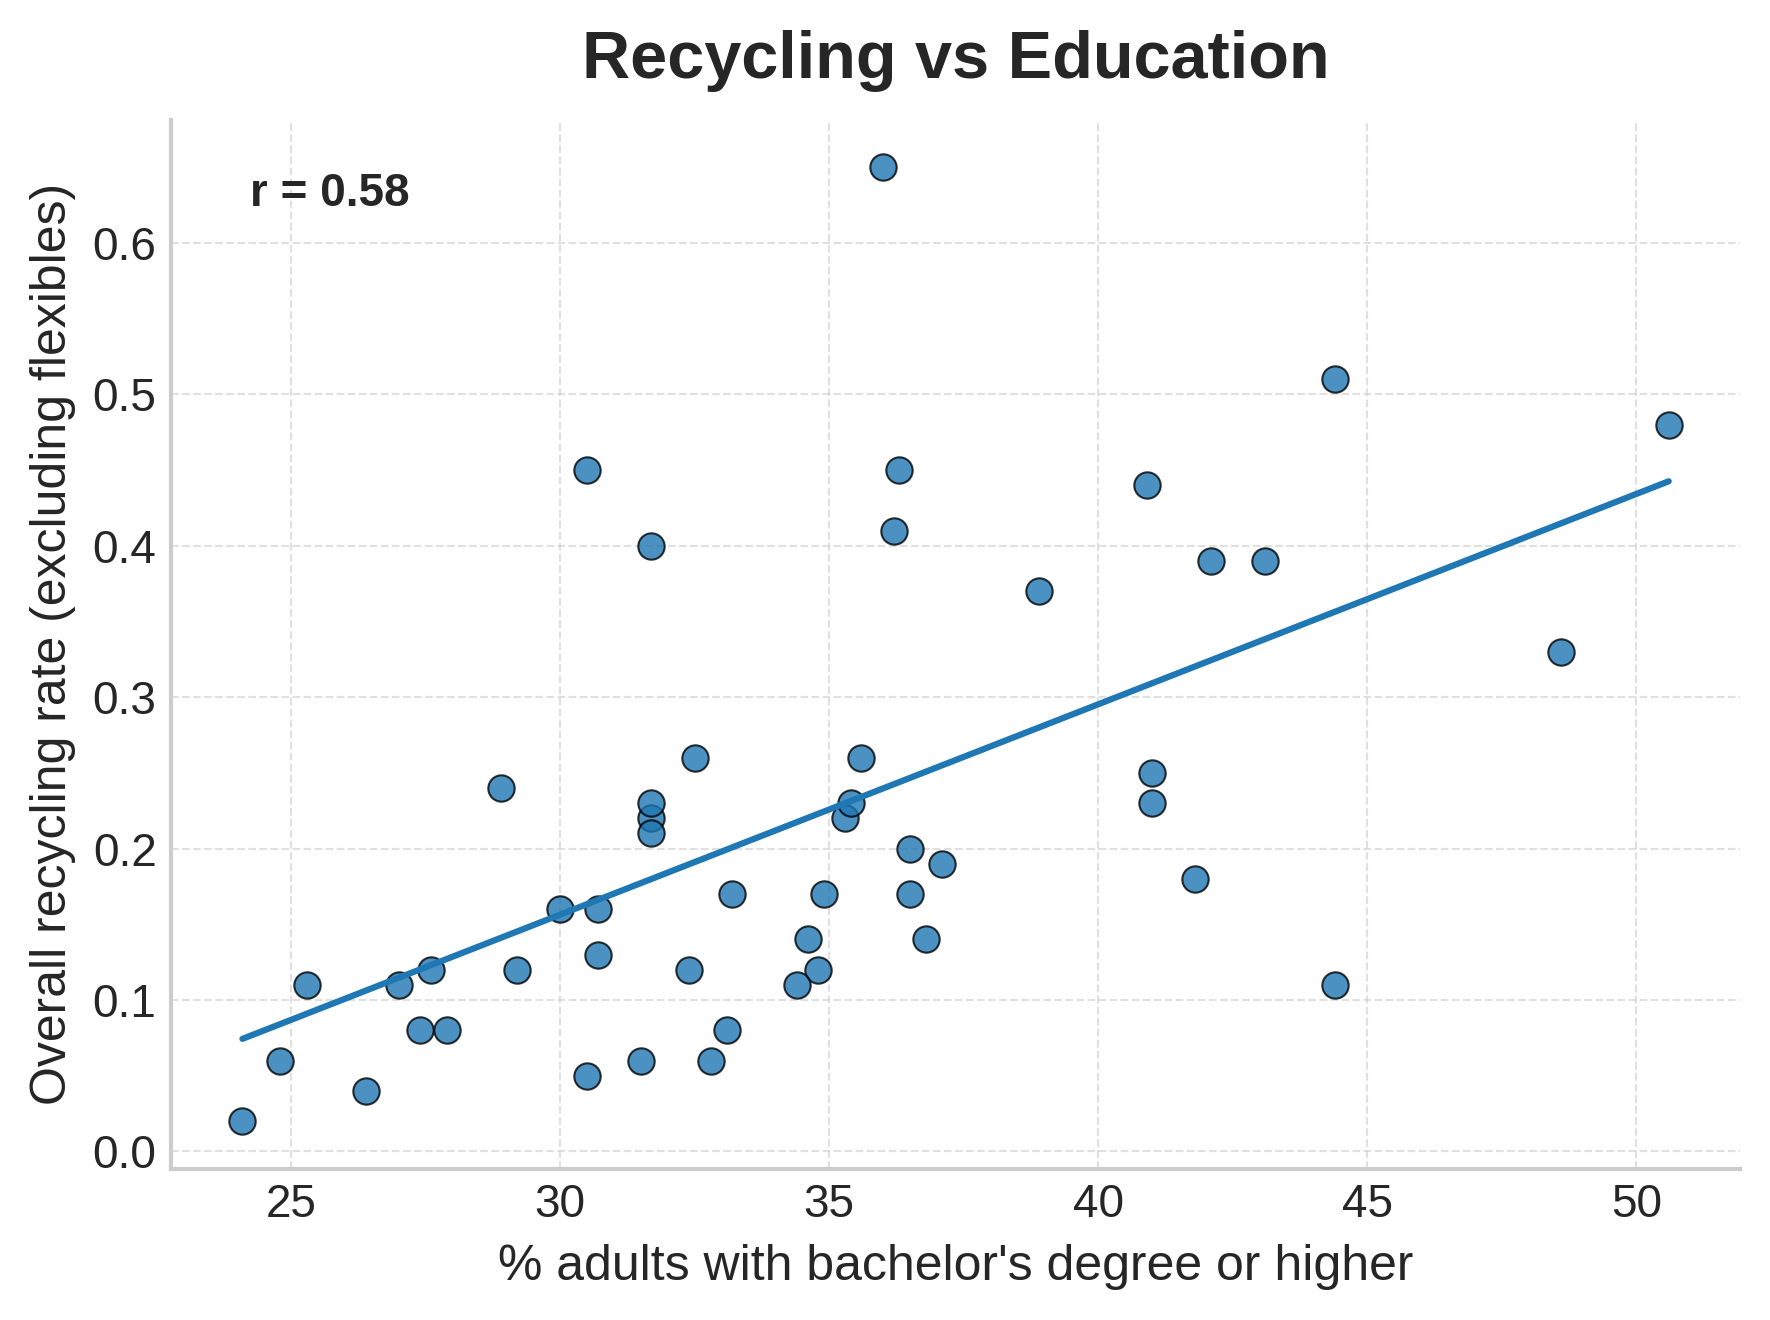

In [34]:
scatter_with_regression(
    merged,
    x_col=education_col,
    y_col=overall_rate_col,
    x_label="% adults with bachelor's degree or higher",
    y_label="Overall recycling rate (excluding flexibles)",
    title="Recycling vs Education",
    annotate_r=True,
    save_path="fig5_1_education_vs_overall_recycling.png",
)


Saved figure to: fig5_2_poverty_vs_overall_recycling.png


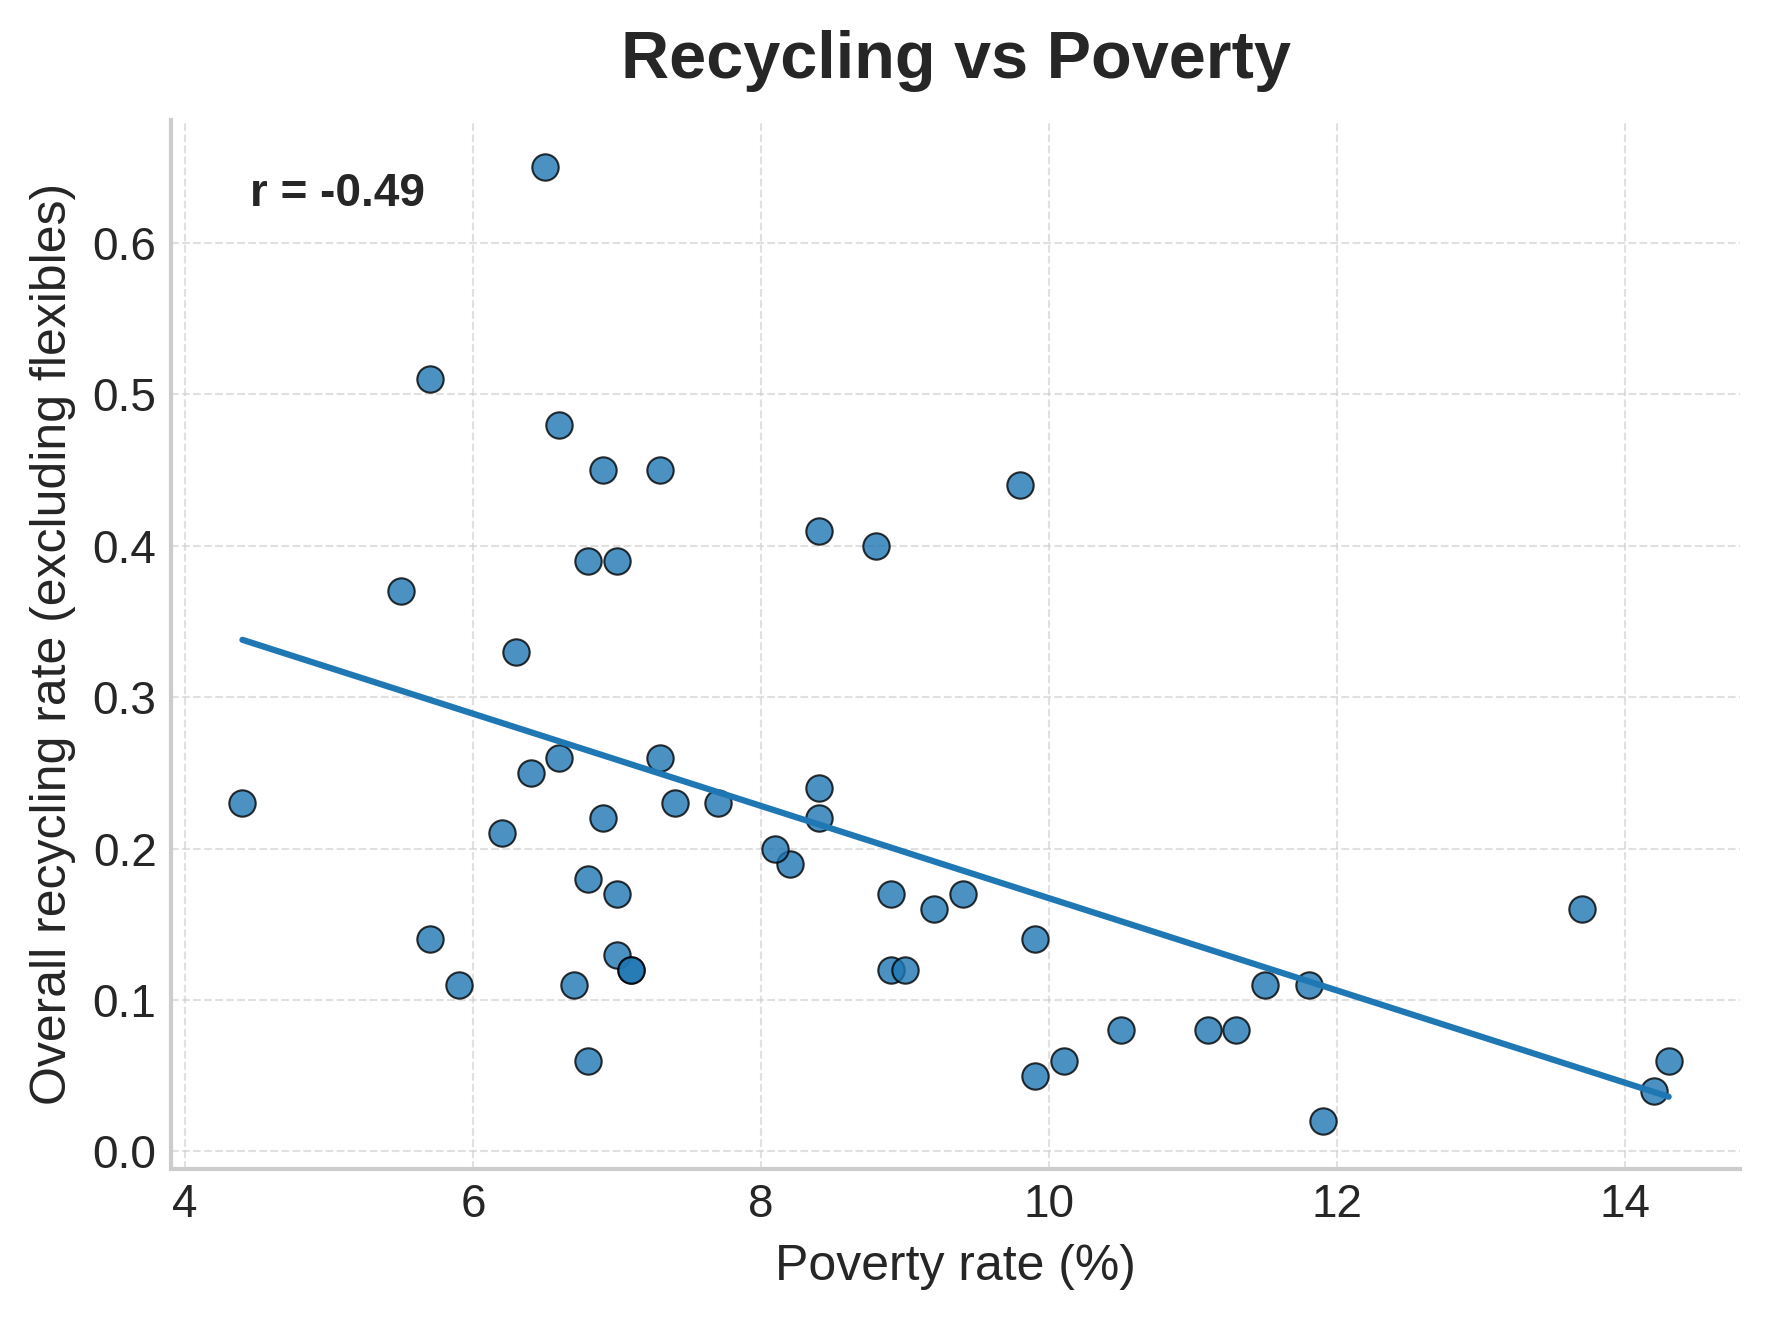

In [35]:
scatter_with_regression(
    merged,
    x_col=poverty_col,
    y_col=overall_rate_col,
    x_label="Poverty rate (%)",
    y_label="Overall recycling rate (excluding flexibles)",
    title="Recycling vs Poverty",
    annotate_r=True,
    save_path="fig5_2_poverty_vs_overall_recycling.png",
)


Saved figure to: fig5_3_income_vs_overall_recycling.png


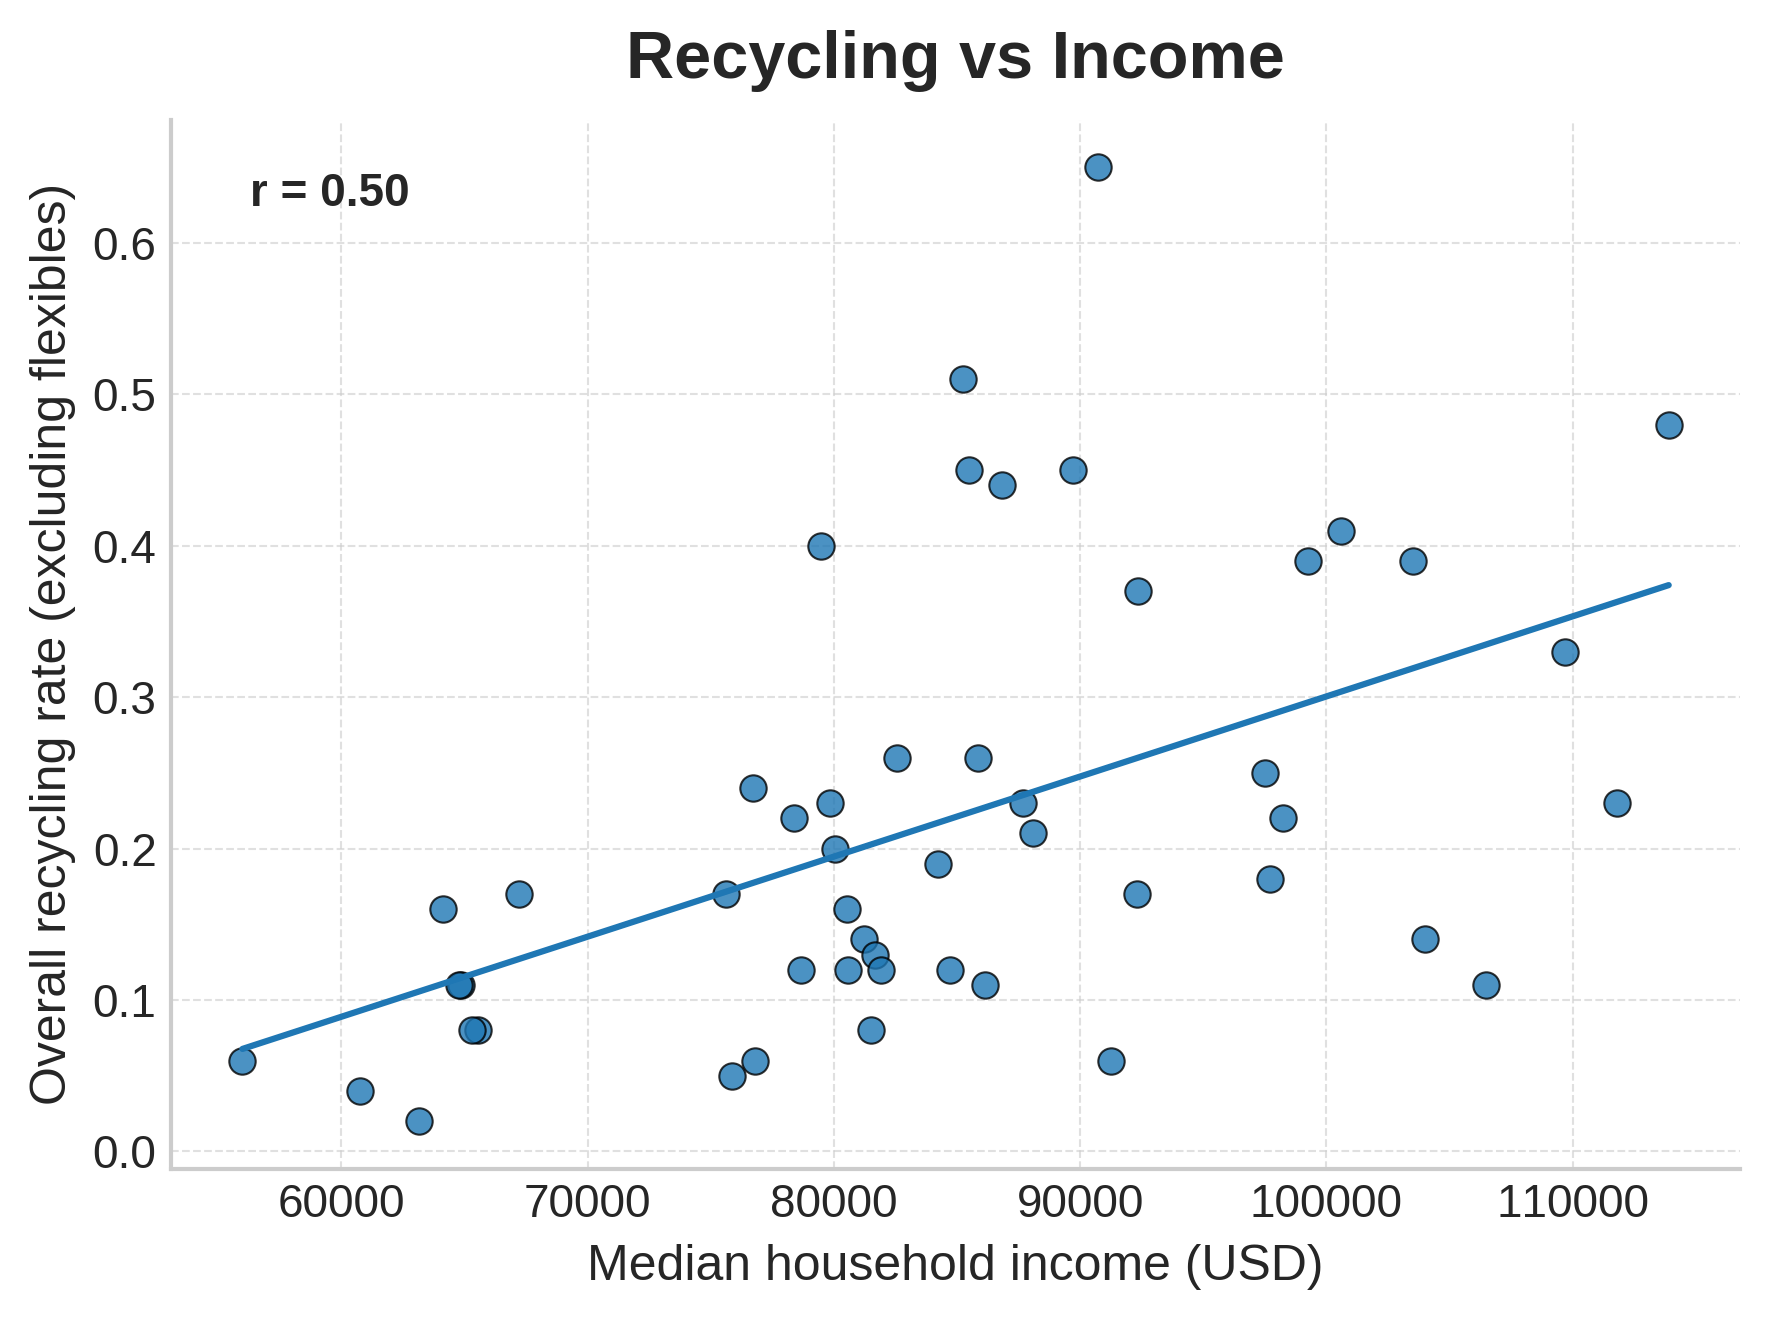

In [36]:
scatter_with_regression(
    merged,
    x_col=income_col,
    y_col=overall_rate_col,
    x_label="Median household income (USD)",
    y_label="Overall recycling rate (excluding flexibles)",
    title="Recycling vs Income",
    annotate_r=True,
    save_path="fig5_3_income_vs_overall_recycling.png",
)


In [37]:
if party_col in merged.columns:
    party_stats = (
        merged[[party_col, overall_rate_col]]
        .dropna()
        .groupby(party_col)[overall_rate_col]
        .agg(["mean", "count"])
    )
    print(party_stats)
else:
    print(f"Column {party_col} not found.")


                                    mean  count
PARTY_OF_GOVERNOR_MAYOR_FOR_DC                 
D                               0.289167     24
R                               0.151538     26


/tmp/ipython-input-67539733.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


Saved figure to: fig6_1_boxplot_recycling_by_party.png


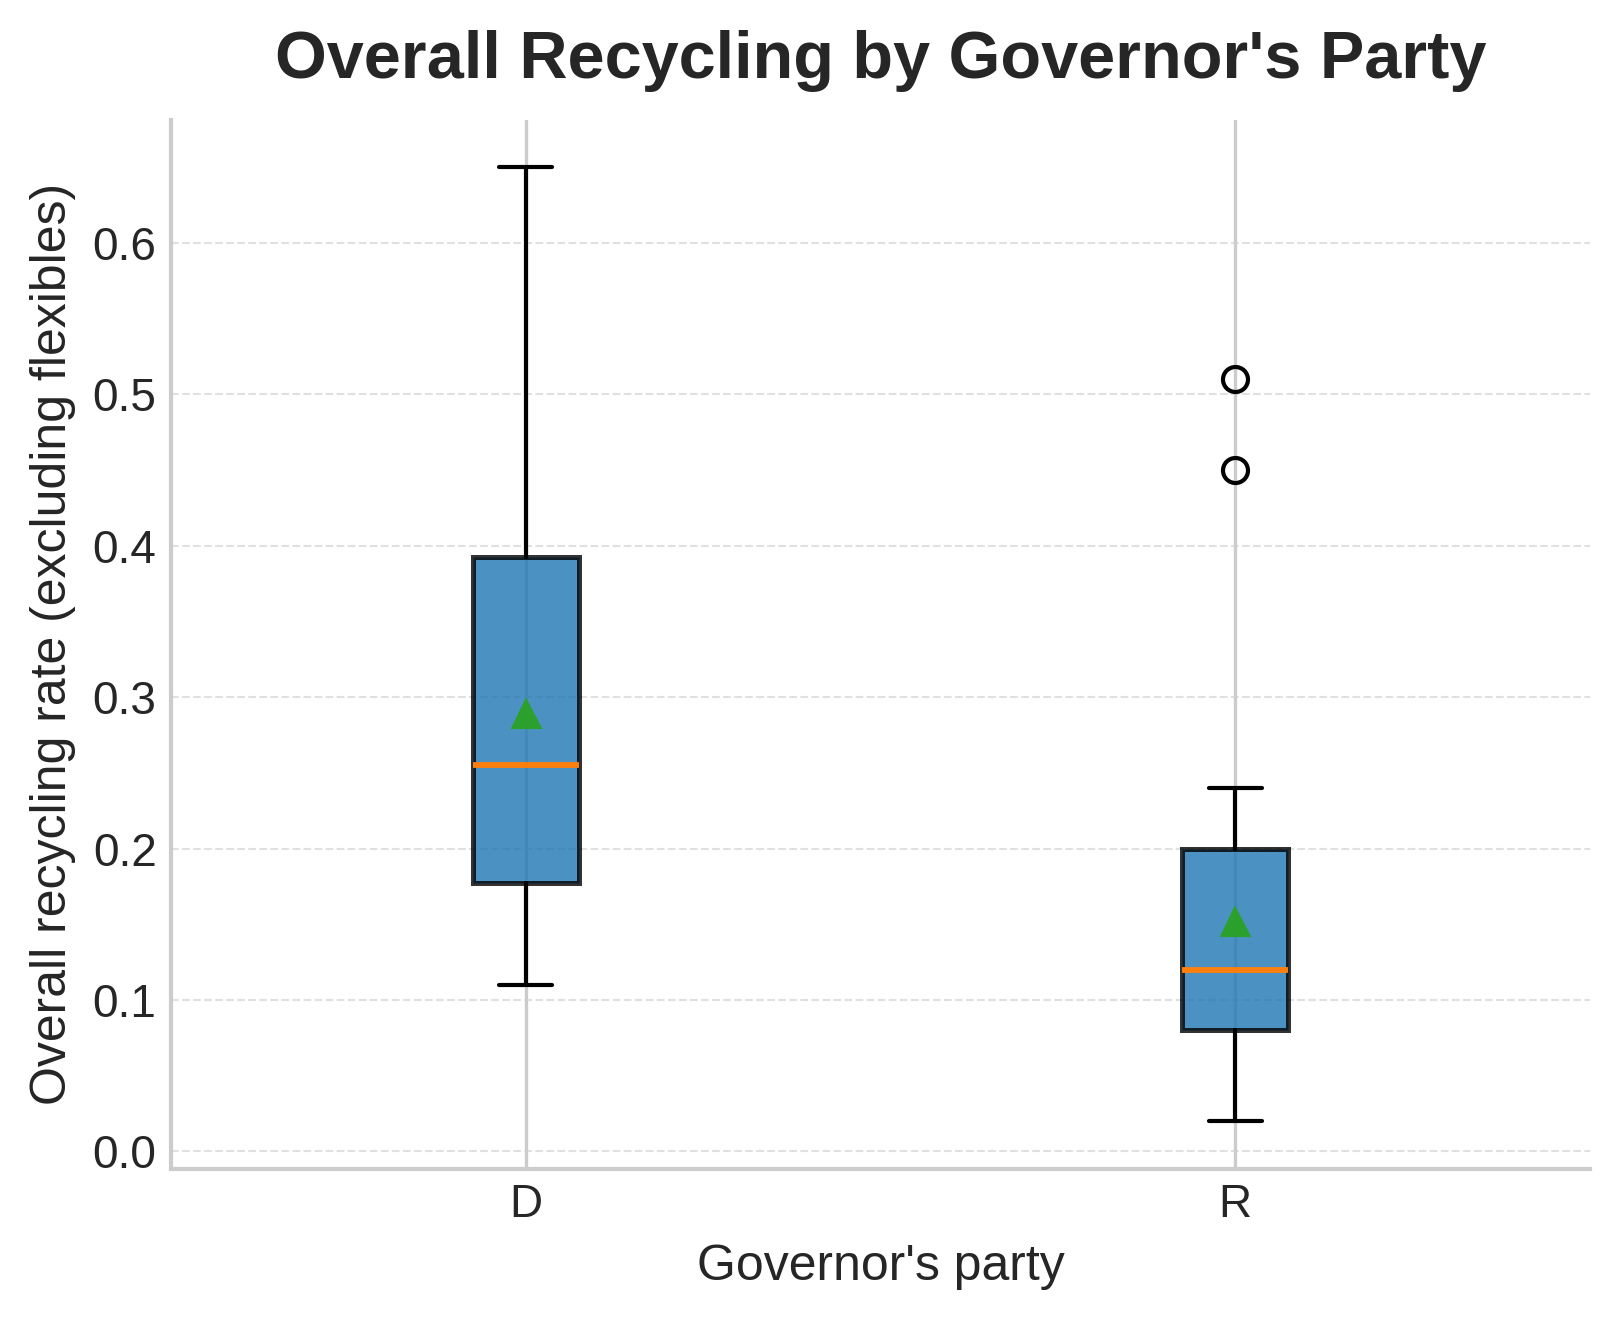

In [38]:
if party_col in merged.columns:
    df_party = merged[[party_col, overall_rate_col]].dropna().copy()
    df_party[party_col] = df_party[party_col].astype(str).str.upper()

    groups = []
    labels = []

    for p in sorted(df_party[party_col].unique()):
        groups.append(df_party.loc[df_party[party_col] == p, overall_rate_col].values)
        labels.append(p)

    fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=300)
    fig.patch.set_alpha(0)
    ax.set_facecolor("none")

    bp = ax.boxplot(
        groups,
        labels=labels,
        showmeans=True,
        patch_artist=True,
    )

    for box in bp["boxes"]:
        box.set_alpha(0.8)
        box.set_linewidth(1.2)
    for whisker in bp["whiskers"]:
        whisker.set_linewidth(1.0)
    for cap in bp["caps"]:
        cap.set_linewidth(1.0)
    for median in bp["medians"]:
        median.set_linewidth(1.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylabel("Overall recycling rate (excluding flexibles)", fontsize=12)
    ax.set_xlabel("Governor's party", fontsize=12)
    ax.set_title(
        "Overall Recycling by Governor's Party",
        fontsize=16,
        pad=10,
        fontweight="bold",
    )

    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

    plt.tight_layout()
    plt.savefig(
        "fig6_1_boxplot_recycling_by_party.png",
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )
    print("Saved figure to: fig6_1_boxplot_recycling_by_party.png")
    plt.show()
else:
    print(f"Column {party_col} not found; skipping boxplot.")


Saved figure to: fig6_2_bar_mean_recycling_by_party.png


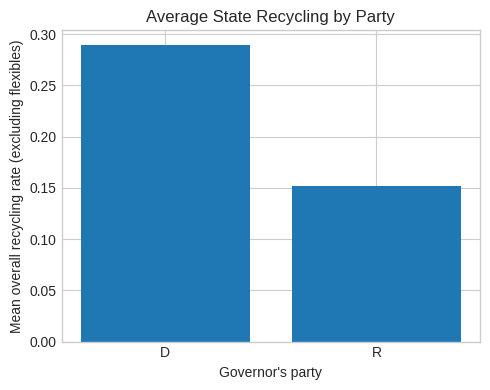

In [39]:
if party_col in merged.columns:
    df_party = merged[[party_col, overall_rate_col]].dropna().copy()
    df_party[party_col] = df_party[party_col].astype(str).str.upper()

    mean_by_party = df_party.groupby(party_col)[overall_rate_col].mean()

    plt.figure(figsize=(5, 4))
    x = np.arange(len(mean_by_party))
    plt.bar(x, mean_by_party.values)
    plt.xticks(x, mean_by_party.index)
    plt.ylabel("Mean overall recycling rate (excluding flexibles)")
    plt.xlabel("Governor's party")
    plt.title("Average State Recycling by Party")
    plt.tight_layout()
    plt.savefig("fig6_2_bar_mean_recycling_by_party.png", dpi=300, bbox_inches="tight")
    print("Saved figure to: fig6_2_bar_mean_recycling_by_party.png")
    plt.show()
else:
    print(f"Column {party_col} not found; skipping bar chart.")
